# ek_baseline_zscore
Causal rolling Z-score per channel · top-p% aggregation · event F0.5 threshold tuning

In [8]:
%%script true
from google.colab import drive
drive.mount('/content/drive')

%cd drive/MyDrive/Colab Notebooks/sentinel
!pip install -e .

import sys
sys.path.insert(0, "/content/drive/MyDrive/Colab Notebooks/sentinel/src")

Mounted at /content/drive
/content/drive/MyDrive/Colab Notebooks/sentinel
Obtaining file:///content/drive/MyDrive/Colab%20Notebooks/sentinel
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for sentinel (pyproject.toml) ... done
  Created wheel for sentinel: filename=sentinel-0.1.0-0.editable-py3-none-any.whl size=1253 sha256=bbf75c545590957b8bbbe2e3c85a7e4ed2459446d86469f682bfda105897a0a5
  Stored in directory: /tmp/pip-ephem-wheel-cache-5jp4e9j8/wheels/0b/1f/c3/dfb5498defd946b02a9af16aa08b88f67e91903544aef346c4
Successfully built sentinel


In [9]:
%%script true
import numpy as np
import pandas as pd
import pyarrow.parquet as pq
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path

from sentinel.ml_logic.metrics import compute_all_metrics, esa_metric
from sentinel.ml_logic.thresholds import tune_threshold

In [10]:
# ── config ───────────────────────────────────────────────────────────────────
FREQ_CHANNELS = [
    'channel_41', 'channel_42', 'channel_43',
    'channel_44', 'channel_45', 'channel_46',
]
TRAIN_FRAC     = 0.70
VAL_FRAC       = 0.15
ROLLING_WINDOW = 300      # causal rolling z-score window
P_GRID         = [0.17, 0.33, 0.5, 0.67, 1.0]

# ── group enable flags ───────────────────────────────────────────────────────
USE_FREQ_CHANNELS = True   # channels 41–46  (optional: with frequency decomposition)
USE_ENV_CHANNELS  = True    # channels 14/21/29  (envelope residual)

# ── envelope residual (channels 14 / 21 / 29) ────────────────────────────────
ENV_CHANNELS  = ['channel_14', 'channel_21', 'channel_29']
ENV_WINDOW    = 300      # rolling min window (≈ fast oscillation period)
ENV_MA_WINDOW = 5_000    # MA window for envelope baseline — tune from ek_envelope_eda

ANOMALY_COLOR = '#e74c3c'
NOMINAL_COLOR = '#2980b9'

RAW_DIR  = Path('./data/raw')
SUB_DIR  = Path('./submissions')
SUB_DIR.mkdir(exist_ok=True)

In [11]:
cols  = ['id', 'is_anomaly'] + FREQ_CHANNELS + ENV_CHANNELS
train = pq.read_table(str(RAW_DIR / 'train.parquet'), columns=cols
                      ).to_pandas().set_index('id')
test  = pq.read_table(str(RAW_DIR / 'test.parquet'),
                      columns=['id'] + FREQ_CHANNELS + ENV_CHANNELS).to_pandas().set_index('id')
print(f'Train: {len(train):,} rows  |  Test: {len(test):,} rows')

Train: 14,728,321 rows  |  Test: 521,280 rows


In [12]:
n       = len(train)
tr_end  = int(n * TRAIN_FRAC)
val_end = int(n * (TRAIN_FRAC + VAL_FRAC))

y_tr       = train['is_anomaly'].values[:tr_end]
y_val      = train['is_anomaly'].values[tr_end:val_end]
y_test_int = train['is_anomaly'].values[val_end:]
print(f'Train: {len(y_tr):,} | Val: {len(y_val):,} | Test_int: {len(y_test_int):,}')
print(f'Val anomaly rate: {y_val.mean():.4%}  |  Test_int: {y_test_int.mean():.4%}')
# X_tr / X_val / X_test_int are set by the "Compose active CHANNELS" cell below

Train: 10,309,824 | Val: 2,209,248 | Test_int: 2,209,249
Val anomaly rate: 10.1136%  |  Test_int: 10.7724%


## [Optional] Frequency decomposition
Пропустить → пайплайн работает с оригинальными 6 каналами.  
Выполнить → `CHANNELS`, `X_tr / X_val / X_test_int` заменяются на подканалы из `SUBCHANNEL_PARTS`.  
Все последующие ячейки (rolling z-score, grid search, global comparison, submission) подхватывают изменение автоматически.

In [13]:
from scipy.ndimage import uniform_filter1d
import json

# ── config ────────────────────────────────────────────────────────────────────
SUBCHANNEL_PARTS  = ['res']
BIG_WINDOW_DECOMP = 50_000
# ─────────────────────────────────────────────────────────────────────────────

if not USE_FREQ_CHANNELS:
    print('FREQ channels disabled (USE_FREQ_CHANNELS=False) — skipping decomposition.')
else:
    freq_map = json.loads(Path('./data/freq_map.json').read_text())

    def _decompose(arr, bw, mw, sw):
        """Three-level cascade decomposition → (sin1, sin2, sin3, residual)."""
        a    = np.asarray(arr, dtype=np.float64)
        sin1 = uniform_filter1d(a,             size=bw, mode='nearest')
        r1   = a - sin1
        s2r  = uniform_filter1d(r1,            size=mw, mode='nearest')
        s3r  = uniform_filter1d(r1 - s2r,     size=sw, mode='nearest')
        sin2 = uniform_filter1d(r1 - s3r,     size=mw, mode='nearest')
        r2   = r1 - sin2
        sin3 = uniform_filter1d(r2,            size=sw, mode='nearest')
        res  = r2 - sin3
        return sin1, sin2, sin3, res

    _base_ch   = [c for c in FREQ_CHANNELS if not c.endswith(('_sin1','_sin2','_sin3','_res'))]
    _part_keys = ['sin1', 'sin2', 'sin3', 'res']

    for df, label in [(train, 'train'), (test, 'test')]:
        print(f'Decomposing {label} ({len(df):,} rows) …')
        for ch in _base_ch:
            T1, T2 = freq_map[ch]
            mw = max(T1 * 2, T2 // 3)
            sw = max(3, T1 // 5)
            parts = _decompose(df[ch].values, BIG_WINDOW_DECOMP, mw, sw)
            for name, arr in zip(_part_keys, parts):
                df[f'{ch}_{name}'] = arr
            print(f'  {ch}: T1={T1}  T2={T2}  sw={sw}  mw={mw}  bw={BIG_WINDOW_DECOMP:,}')

    FREQ_CHANNELS = [f'{ch}_{p}' for ch in _base_ch for p in SUBCHANNEL_PARTS]
    print(f'\nFREQ_CHANNELS ({len(FREQ_CHANNELS)}): {FREQ_CHANNELS}')

Decomposing train (14,728,321 rows) …
  channel_41: T1=98  T2=2159  sw=19  mw=719  bw=50,000
  channel_42: T1=98  T2=2161  sw=19  mw=720  bw=50,000
  channel_43: T1=98  T2=2161  sw=19  mw=720  bw=50,000
  channel_44: T1=98  T2=2159  sw=19  mw=719  bw=50,000
  channel_45: T1=98  T2=2161  sw=19  mw=720  bw=50,000
  channel_46: T1=98  T2=2161  sw=19  mw=720  bw=50,000
Decomposing test (521,280 rows) …
  channel_41: T1=98  T2=2159  sw=19  mw=719  bw=50,000
  channel_42: T1=98  T2=2161  sw=19  mw=720  bw=50,000
  channel_43: T1=98  T2=2161  sw=19  mw=720  bw=50,000
  channel_44: T1=98  T2=2159  sw=19  mw=719  bw=50,000
  channel_45: T1=98  T2=2161  sw=19  mw=720  bw=50,000
  channel_46: T1=98  T2=2161  sw=19  mw=720  bw=50,000

FREQ_CHANNELS (6): ['channel_41_res', 'channel_42_res', 'channel_43_res', 'channel_44_res', 'channel_45_res', 'channel_46_res']


In [14]:
# ── [Optional] Envelope residual features — channels 14 / 21 / 29 ────────────
# feature = rolling_min(ENV_WINDOW) − centered_MA(ENV_MA_WINDOW)
# column suffix: _envr
# ─────────────────────────────────────────────────────────────────────────────

_envr_names = []   # populated below if USE_ENV_CHANNELS is True

if not USE_ENV_CHANNELS:
    print('ENV channels disabled (USE_ENV_CHANNELS=False) — skipping.')
else:
    def _envr_col(series, env_w, ma_w):
        """Causal rolling min → subtract centered MA → envelope residual."""
        env = series.rolling(window=env_w, min_periods=1).min()
        ma  = env.rolling(window=ma_w, min_periods=1, center=True).mean()
        return (env - ma).values

    print(f'Computing envelope residuals  ENV_WINDOW={ENV_WINDOW}  ENV_MA_WINDOW={ENV_MA_WINDOW} …')
    for df, label in [(train, 'train'), (test, 'test')]:
        for ch in ENV_CHANNELS:
            df[ch + '_envr'] = _envr_col(df[ch], ENV_WINDOW, ENV_MA_WINDOW)
    print('Done.')

    ENV_CHANNELS = [ch + '_envr' for ch in ENV_CHANNELS]
    print(f'ENV features: {ENV_CHANNELS}')

Computing envelope residuals  ENV_WINDOW=300  ENV_MA_WINDOW=5000 …
Done.
ENV features: ['channel_14_envr', 'channel_21_envr', 'channel_29_envr']


In [15]:
# ── Compose active CHANNELS ──────────────────────────────────────────────────
# Always run this cell after the two optional cells above.
# Controls which channel groups flow into z-score, grid search, and submission.
# ─────────────────────────────────────────────────────────────────────────────
_active = []
if USE_FREQ_CHANNELS:
    _active += FREQ_CHANNELS   # raw channel_41–46, or _res names after decomp cell
if USE_ENV_CHANNELS:
    _active += ENV_CHANNELS

assert _active, 'No channels enabled — set at least one USE_* flag to True in config'

CHANNELS   = _active
X_tr       = train[CHANNELS].iloc[:tr_end]
X_val      = train[CHANNELS].iloc[tr_end:val_end]
X_test_int = train[CHANNELS].iloc[val_end:]
print(f'Active CHANNELS ({len(CHANNELS)}): {CHANNELS}')

Active CHANNELS (9): ['channel_41_res', 'channel_42_res', 'channel_43_res', 'channel_44_res', 'channel_45_res', 'channel_46_res', 'channel_14_envr', 'channel_21_envr', 'channel_29_envr']


In [16]:
def rolling_zscore_df(df, window):
    """Causal per-channel rolling Z-score (backward-looking)."""
    roll = df.rolling(window=window, min_periods=max(2, window // 10))
    mu   = roll.mean()
    sd   = roll.std().fillna(1.0).clip(lower=1e-8)
    return ((df - mu) / sd).fillna(0.0)

def rolling_zscore_multiwindow(df, channels, window_by_part):
    """Z-score с окном, соответствующим частотной части канала."""
    parts = {}
    for ch in channels:
        part = ch.rsplit('_', 1)[-1]           # 'sin1' / 'res' / etc.
        w    = window_by_part.get(part, 1000)  # fallback для оригинальных каналов
        roll = df[[ch]].rolling(window=w, min_periods=max(2, w // 10))
        mu   = roll.mean()
        sd   = roll.std().fillna(1.0).clip(lower=1e-8)
        parts[ch] = ((df[[ch]] - mu) / sd).fillna(0.0)[ch]
    return pd.DataFrame(parts)


def top_p_mean(z_arr, p):
    """Mean of top-p fraction of channels by abs Z-score. Vectorised."""
    n_top = max(1, int(z_arr.shape[1] * p))
    z_abs = np.abs(z_arr)
    top   = np.partition(z_abs, -n_top, axis=1)[:, -n_top:]
    return top.mean(axis=1)

In [17]:
print(f'Computing rolling Z-score (window={ROLLING_WINDOW:,}) on {len(train):,} rows …')
#z_full     = rolling_zscore_df(train[CHANNELS], ROLLING_WINDOW)
#std_tr = train[CHANNELS].iloc[:tr_end].std()
#z_full = (train[CHANNELS] - 0) / std_tr
freq_cols = [c for c in CHANNELS if not c.endswith('_envr')]
env_cols  = [c for c in CHANNELS if c.endswith('_envr')]

parts = []
if freq_cols:
    parts.append(rolling_zscore_df(train[freq_cols], ROLLING_WINDOW))
if env_cols:
    std_tr_env = train[env_cols].iloc[:tr_end].std()
    parts.append(train[env_cols] / std_tr_env)

z_full = pd.concat(parts, axis=1)[CHANNELS]

z_tr       = z_full.iloc[:tr_end]
z_val      = z_full.iloc[tr_end:val_end]
z_test_int = z_full.iloc[val_end:]
print('Done.')

# Grid search: for each p, tune threshold and record best event F0.5
print(f'{"p":>6}  {"F0.5":>7}  {"thr":>10}')
print('-' * 30)

best_score, best_p, best_thr, best_result = -1, None, None, None

for p in P_GRID:
    scores_val = top_p_mean(z_val.values, p=p)
    res = tune_threshold(scores_val, y_val, metric_fn=esa_metric,
                        lo_percentile=(0, 90),
                        hi_percentile=(1, 99.99), n_sweep=120)
    print(f'{p:>6.2f}  {res["score"]:>7.4f}  {res["threshold"]:>10.4g}')
    if res['score'] > best_score:
        best_score, best_p, best_thr, best_result = (
            res['score'], p, res['threshold'], res)

print(f'\nBest  p={best_p}  threshold={best_thr:.4g}  F0.5={best_score:.4f}')

Computing rolling Z-score (window=300) on 14,728,321 rows …
Done.
     p     F0.5         thr
------------------------------
  0.17   0.6549       6.994
  0.33   0.7258        12.4
  0.50   0.7258       11.08
  0.67   0.6897       9.325
  1.00   0.7143       4.792

Best  p=0.33  threshold=12.4  F0.5=0.7258


In [18]:
scores_val = top_p_mean(z_val.values, p=best_p)
y_pred_val = (scores_val > best_thr).astype(np.int8)

metrics = compute_all_metrics(y_val, y_pred_val)
print('\n── Validation metrics ─────────────────────────────')
for k, v in metrics.items():
    print(f'  {k:<28} {v}')


── Validation metrics ─────────────────────────────
  event_f05                    0.725806
  event_f1                     0.514286
  event_f2                     0.39823
  event_precision              1.0
  event_recall                 0.346154
  esa_f05                      0.725806
  esa_precision                1.0
  esa_recall                   0.346154
  esa_tnr                      1.0
  event_detection_rate         0.346154
  tp_events                    9
  n_events                     26
  fp_pred_events               0
  pa_f1                        0.494852
  pa_precision                 1.0
  pa_recall                    0.328773
  row_precision                1.0
  row_recall                   0.005863
  row_f1                       0.011658


In [19]:
# ── Internal test — threshold FROZEN from val tuning (no re-tuning) ───────────
scores_test_int_arr = top_p_mean(z_test_int.values, p=best_p)
y_pred_test_int     = (scores_test_int_arr > best_thr).astype(np.int8)

metrics_test_int = compute_all_metrics(y_test_int, y_pred_test_int)
print('── Internal test metrics ─────────────────────────')
for k, v in metrics_test_int.items():
    print(f'  {k:<28} {v}')

── Internal test metrics ─────────────────────────
  event_f05                    0.75
  event_f1                     0.585366
  event_f2                     0.48
  event_precision              0.923077
  event_recall                 0.428571
  esa_f05                      0.74976
  esa_precision                0.922623
  esa_recall                   0.428571
  esa_tnr                      0.999508
  event_detection_rate         0.428571
  tp_events                    12
  n_events                     28
  fp_pred_events               1
  pa_f1                        0.752361
  pa_precision                 0.99332
  pa_recall                    0.605483
  row_precision                0.823754
  row_recall                   0.01903
  row_f1                       0.037201


## Global Z-score comparison
Фиксированная нормировка (μ, σ от X_tr) + тот же `top_p_mean` + тот же `tune_threshold`.  
Изолирует эффект **локального окна** от агрегации и тюнинга порога.  
Если F0.5 ≈ квантильному baseline → разница была именно в нормировке.  
Если F0.5 ≈ rolling → локальное окно бесполезно.

In [20]:
%%script true
# Фиксированная нормировка на статистиках X_tr
mu_tr = X_tr.mean()
sd_tr = X_tr.std().clip(lower=1e-8)

z_val_global      = (X_val      - mu_tr) / sd_tr
z_test_int_global = (X_test_int - mu_tr) / sd_tr

# Grid search — тот же P_GRID, тот же tune_threshold
print(f'{"p":>6}  {"F0.5":>7}  {"thr":>10}')
print('-' * 30)

best_score_g, best_p_g, best_thr_g = -1, None, None

for p in P_GRID:
    scores_val_g = top_p_mean(z_val_global.values, p=p)
    res = tune_threshold(scores_val_g, y_val, metric_fn=event_f05,
                         lo_percentile=(0, 90.0),
                         hi_percentile=(1, 99.9), n_sweep=120)
    print(f'{p:>6.2f}  {res["score"]:>7.4f}  {res["threshold"]:>10.4g}')
    if res['score'] > best_score_g:
        best_score_g, best_p_g, best_thr_g = res['score'], p, res['threshold']

print(f'\nBest  p={best_p_g}  threshold={best_thr_g:.4g}  F0.5={best_score_g:.4f}')

# Val metrics
scores_val_g_best = top_p_mean(z_val_global.values, p=best_p_g)
y_pred_val_g      = (scores_val_g_best > best_thr_g).astype(np.int8)
metrics_val_g     = compute_all_metrics(y_val, y_pred_val_g)

# Test_int metrics (порог заморожен)
scores_test_int_g = top_p_mean(z_test_int_global.values, p=best_p_g)
y_pred_test_int_g = (scores_test_int_g > best_thr_g).astype(np.int8)
metrics_test_g    = compute_all_metrics(y_test_int, y_pred_test_int_g)

# Сравнительная таблица
KEY_METRICS = ['event_f05', 'event_precision', 'event_recall',
               'fp_pred_events', 'event_detection_rate']
print(f'\n{"metric":<24}  {"rolling":>10}  {"global":>10}')
print('-' * 48)
for k in KEY_METRICS:
    rv = metrics[k]          # rolling (вычислен выше)
    gv = metrics_val_g[k]
    print(f'{k:<24}  {rv:>10}  {gv:>10}')

In [21]:
from sentinel.ml_logic.data import find_anomaly_segments

def split_tp_fn(y_true, y_pred):
    true_segs = find_anomaly_segments(y_true)
    pred_segs = find_anomaly_segments(y_pred)
    tp, fn = [], []
    for ts in true_segs:
        hit = any(ps['end'] >= ts['start'] and ps['start'] <= ts['end']
                  for ps in pred_segs)
        (tp if hit else fn).append(ts)
    return tp, fn


def plot_score_timeline(scores, y_true, thr, tp_events, fn_events, title=''):
    """Score over time with TP/FN event spans. Subsampled for speed."""
    step = max(1, len(scores) // 50_000)
    idx  = np.arange(0, len(scores), step)
    fig, ax = plt.subplots(figsize=(18, 3))
    ax.plot(idx, scores[idx], lw=0.4, color=NOMINAL_COLOR, label='anomaly score')
    ax.axhline(thr, color='black', lw=1.2, ls='--', label=f'threshold {thr:.4g}')
    for ev in tp_events:
        ax.axvspan(ev['start'], ev['end'], color='green', alpha=0.25, linewidth=0)
    for ev in fn_events:
        ax.axvspan(ev['start'], ev['end'], color=ANOMALY_COLOR, alpha=0.35, linewidth=0)
    from matplotlib.patches import Patch
    ax.legend(handles=[
        ax.lines[0], ax.lines[1],
        Patch(color='green', alpha=0.4, label=f'TP events ({len(tp_events)})'),
        Patch(color=ANOMALY_COLOR, alpha=0.4, label=f'FN events ({len(fn_events)})'),
    ], fontsize=8, loc='upper right')
    ax.set_xlabel('Val row index'); ax.set_ylabel('Score')
    ax.set_title(title or 'Score timeline')
    ax.set_ylim(-0.5 * thr, 3 * thr)
    plt.tight_layout(); plt.show()


def plot_score_dist(scores, y_true, thr):
    """Score histogram: nominal vs anomaly."""
    fig, ax = plt.subplots(figsize=(10, 3))
    ax.hist(scores[y_true == 0], bins=300, density=True,
            color=NOMINAL_COLOR, alpha=0.6, label='nominal')
    ax.hist(scores[y_true == 1], bins=80, density=True,
            color=ANOMALY_COLOR, alpha=0.7, label='anomaly')
    ax.axvline(thr, color='black', ls='--', lw=1.2, label=f'threshold {thr:.4g}')
    ax.set_xlabel('Score'); ax.set_ylabel('Density')
    ax.set_title('Score distribution: nominal vs anomaly')
    ax.legend(fontsize=9); plt.tight_layout(); plt.show()


def plot_duration_hist(tp_events, fn_events):
    """Event duration distribution: TP (caught) vs FN (missed)."""
    tp_len = [e['length'] for e in tp_events]
    fn_len = [e['length'] for e in fn_events]
    bins   = np.logspace(0, 6, 50)
    fig, axes = plt.subplots(1, 2, figsize=(13, 3), sharey=True)
    for ax, lens, color, label in [
        (axes[0], tp_len, 'green',     f'TP — caught ({len(tp_len)})'),
        (axes[1], fn_len, ANOMALY_COLOR, f'FN — missed ({len(fn_len)})'),
    ]:
        if lens:
            ax.hist(lens, bins=bins, color=color, alpha=0.75)
        ax.set_xscale('log'); ax.set_xlabel('Event length (rows)')
        ax.set_ylabel('Count'); ax.set_title(label)
    plt.suptitle('Event duration distribution (log scale)', y=1.02)
    plt.tight_layout(); plt.show()

    if tp_len and fn_len:
        print(f'TP median length: {int(np.median(tp_len)):,}  '
              f'| FN median length: {int(np.median(fn_len)):,}')


def plot_missed_zoom(fn_events, scores, y_true, X_val_df, channels, thr,
                     n_show=3, margin=500):
    """Zoom on up to n_show missed events: raw channels + score."""
    show = fn_events[:n_show]
    if not show:
        print('No missed events to display.'); return
    fig, axes = plt.subplots(len(show), 1, figsize=(15, 4.5 * len(show)),
                             squeeze=False)
    for ax_row, ev in zip(axes, show):
        ax = ax_row[0]
        s  = max(0, ev['start'] - margin)
        e  = min(len(scores) - 1, ev['end'] + margin)
        xs = np.arange(s, e + 1)
        for ch in channels:
            ax.plot(xs, X_val_df[ch].values[s: e + 1], lw=0.5, alpha=0.7, label=ch)
        ax.axvspan(ev['start'], ev['end'], color=ANOMALY_COLOR, alpha=0.25, linewidth=0)
        ax2 = ax.twinx()
        ax2.plot(xs, scores[s: e + 1], color='orange', lw=0.9, alpha=0.8, label='score')
        ax2.axhline(thr, color='black', ls='--', lw=1, alpha=0.7)
        ax2.set_ylabel('Score', color='orange')
        ax.set_title(f"Missed event  start={ev['start']:,}  "
                     f"end={ev['end']:,}  len={ev['length']:,}")
        ax.legend(fontsize=7, loc='upper left', ncol=len(channels))
    plt.tight_layout(); plt.show()

## Viz 1 — Score timeline

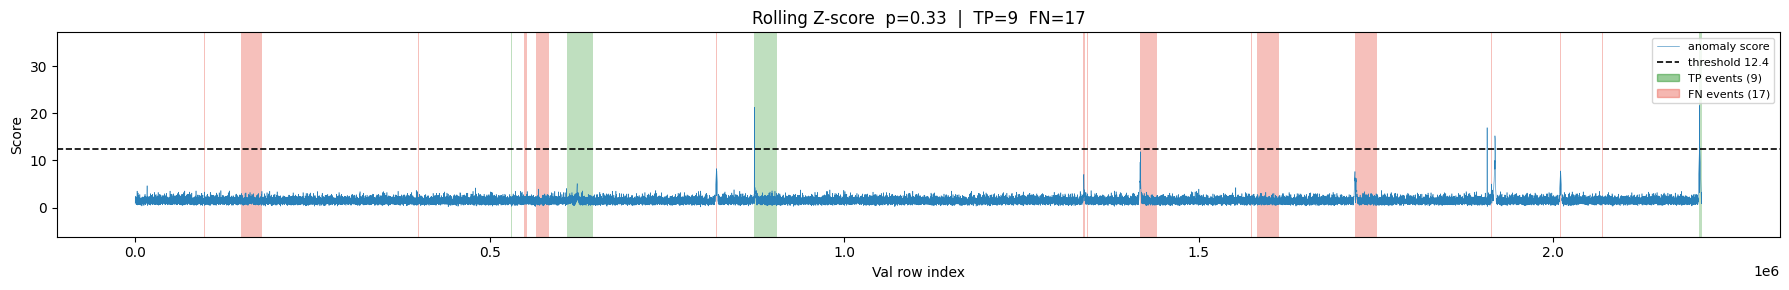

In [22]:
tp_events, fn_events = split_tp_fn(y_val, y_pred_val)
plot_score_timeline(
    scores_val, y_val, best_thr, tp_events, fn_events,
    title=f'Rolling Z-score  p={best_p}  |  '
          f'TP={len(tp_events)}  FN={len(fn_events)}')

## Viz 2 — Score distribution

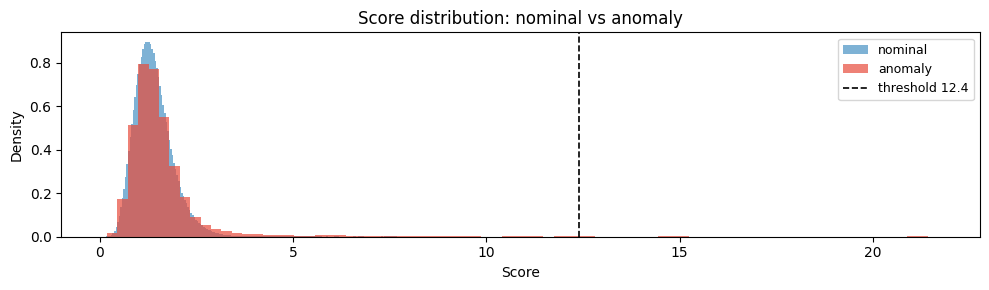

In [23]:
plot_score_dist(scores_val, y_val, best_thr)

## Viz 3 — Event duration: TP vs FN

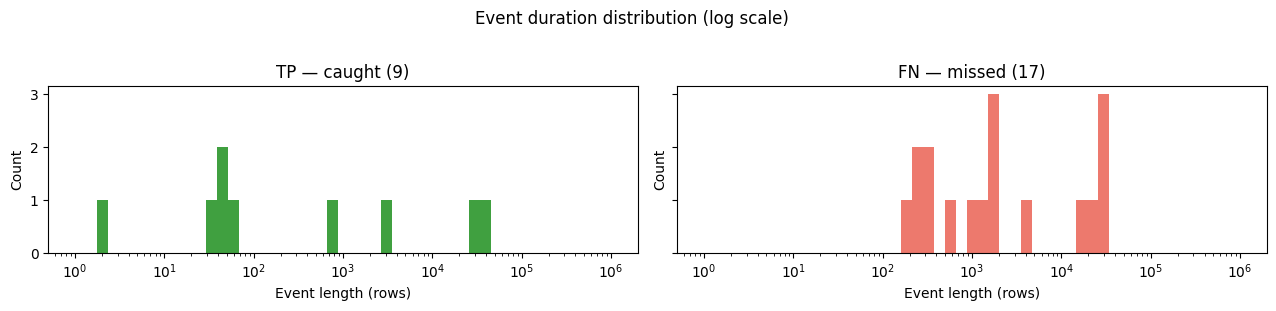

TP median length: 57  | FN median length: 1,755


In [24]:
plot_duration_hist(tp_events, fn_events)

## Viz 4 — Zoom on missed events

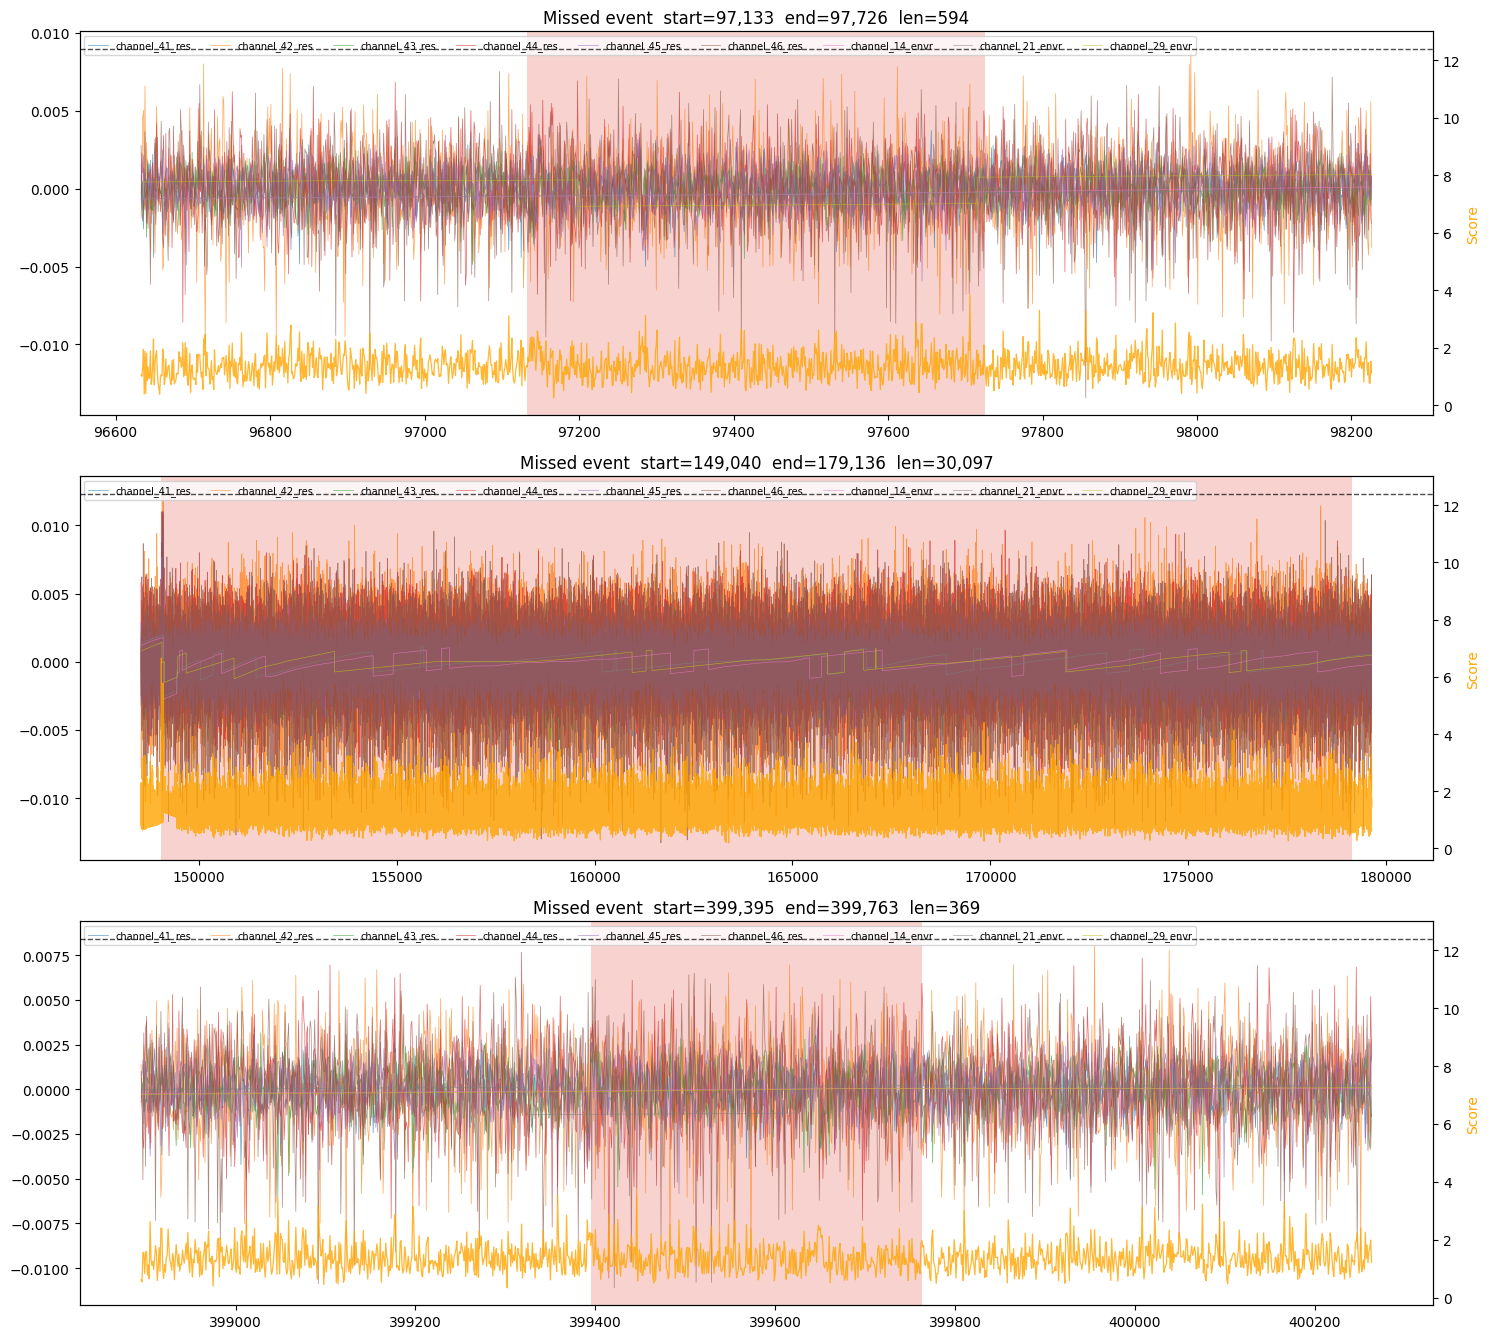

In [25]:
plot_missed_zoom(fn_events, scores_val, y_val, X_val, CHANNELS, best_thr)

## FN Event Explorer
Детальный анализ пропущенных аномалий по длине.

| Ячейка | Что показывает |
|---|---|
| Config | Выбор событий по длине, списки каналов |
| Decomposed channels | Raw + sin1/sin2/sin3/res на окне вокруг аномалии |
| Z-score heatmap | \|z\| по каналам × время + aggregated score vs threshold |
| Other channels | Raw + MA(50 000) + residual для новых каналов |

In [26]:
# ── FN explorer config ────────────────────────────────────────────────────────
# Base channel names (channel_XX) — not _res/_sin2 variants
VIZ_CHANNELS_DECOMP = ['channel_41']
#VIZ_CHANNELS_DECOMP = ['channel_41', 'channel_42', 'channel_43',
#                        'channel_44', 'channel_45', 'channel_46']
names = ['channel_' + str(n) for n in [14, 21, 29]]
VIZ_CHANNELS_OTHER  = names       # other channel names to inspect (raw+MA+residual)
FN_LEN_MIN          = 0
FN_LEN_MAX          = 20000
MARGIN_EXPLORE      = 2_000     # context rows on each side of anomaly
N_EVENTS_SHOW       = 3
MA_VIZ_WINDOW       = 50_000    # for VIZ_CHANNELS_OTHER slow-trend panel
# ─────────────────────────────────────────────────────────────────────────────

fn_target = sorted(
    [ev for ev in fn_events if FN_LEN_MIN <= ev['length'] <= FN_LEN_MAX],
    key=lambda e: e['length'],
)[1:-1]

print([ev for ev in fn_events])

print(f'FN events length {FN_LEN_MIN}–{FN_LEN_MAX}: {len(fn_target)} selected')
for i, ev in enumerate(fn_target):
    score_in_event = scores_val[ev['start'] : ev['end'] + 1]
    print(f'  [{i}] start={ev["start"]:,}  end={ev["end"]:,}  '
          f'len={ev["length"]:,}  '
          f'max_score={score_in_event.max():.3f}  '
          f'gap_to_thr={best_thr - score_in_event.max():.3f}')

# Pre-load VIZ_CHANNELS_OTHER — train was loaded with CHANNELS only
if VIZ_CHANNELS_OTHER:
    print(f'\nLoading extra channels for visualization: {VIZ_CHANNELS_OTHER} …')
    _train_other = pq.read_table(
        str(RAW_DIR / 'train.parquet'), columns=VIZ_CHANNELS_OTHER
    ).to_pandas()
    print(f'Done. Shape: {_train_other.shape}')
else:
    _train_other = pd.DataFrame()

[{'start': 97133, 'end': 97726, 'length': 594}, {'start': 149040, 'end': 179136, 'length': 30097}, {'start': 399395, 'end': 399763, 'length': 369}, {'start': 548497, 'end': 552855, 'length': 4359}, {'start': 565099, 'end': 584013, 'length': 18915}, {'start': 819541, 'end': 819876, 'length': 336}, {'start': 1337362, 'end': 1339200, 'length': 1839}, {'start': 1342475, 'end': 1344310, 'length': 1836}, {'start': 1417019, 'end': 1440576, 'length': 23558}, {'start': 1556161, 'end': 1556436, 'length': 276}, {'start': 1573916, 'end': 1575670, 'length': 1755}, {'start': 1581488, 'end': 1613376, 'length': 31889}, {'start': 1720291, 'end': 1751616, 'length': 31326}, {'start': 1912322, 'end': 1912508, 'length': 187}, {'start': 1912819, 'end': 1913928, 'length': 1110}, {'start': 2009869, 'end': 2010147, 'length': 279}, {'start': 2069274, 'end': 2070523, 'length': 1250}]
FN events length 0–20000: 11 selected
  [0] start=1,556,161  end=1,556,436  len=276  max_score=3.340  gap_to_thr=9.056
  [1] start

In [27]:
from scipy.ndimage import uniform_filter1d as _uf1d
import json as _json

_freq_map  = _json.loads(Path('./data/freq_map.json').read_text())
_BIG_WIN   = 50_000


def _decompose_2pass(arr, bw, mw, sw):
    """Two-pass cascade decomposition (ek_freq_eda cell 8f3e7f44).

    Pass 1: rough sin3 to isolate T1 contamination in r1.
    Pass 2: subtract sin3_rough from r1, then re-extract sin2 cleanly.
    """
    a          = np.asarray(arr, dtype=np.float64)
    sin1       = _uf1d(a,              size=bw, mode='nearest')
    r1         = a - sin1
    sin2_rough = _uf1d(r1,             size=mw, mode='nearest')
    sin3_rough = _uf1d(r1 - sin2_rough, size=sw, mode='nearest')
    sin2       = _uf1d(r1 - sin3_rough, size=mw, mode='nearest')
    r2         = r1 - sin2
    sin3       = _uf1d(r2,             size=sw, mode='nearest')
    res        = r2 - sin3
    return sin1, sin2, sin3, res


def plot_fn_decomposed(ev, channels=None, bw=_BIG_WIN):
    """Cascaded decomposition around one FN event — style from ek_freq_eda Viz 4.

    4 panels per channel:
      a) raw + sin1 (slow trend, full context)
      b) r1  + sin2 (medium ~T2, zoom 8×T2 before anomaly)
      c) r2  + sin3 (short  ~T1, zoom 10×T1 before anomaly)
      d) residual   (same zoom as c)

    Anomaly span is highlighted in every panel.
    Vertical tick marks at each period to aid visual counting.
    """
    if channels is None:
        channels = VIZ_CHANNELS_DECOMP

    # Convert val-relative event to train-absolute indices
    an_s_tr = tr_end + ev['start']
    an_e_tr = tr_end + ev['end']

    for ch in channels:
        T1, T2 = _freq_map.get(ch, [98, 2000])
        mw = max(T1 * 2, T2 // 3)
        sw = max(3,  T1 // 5)

        # Context window: 3×bw before, 1×bw after
        win_s = max(0, an_s_tr - 3 * bw)
        win_e = min(len(train), an_e_tr + 1 + bw)
        raw   = train[ch].values[win_s:win_e].astype(np.float64)

        sin1, sin2, sin3, res = _decompose_2pass(raw, bw, mw, sw)
        r1 = raw - sin1
        r2 = r1  - sin2
        r3 = r2  - sin3

        n   = len(raw)
        a0  = an_s_tr - win_s       # anomaly start in local coords
        a1  = an_e_tr - win_s + 1   # exclusive end

        n_med = min(8  * T2, n)
        n_sml = min(10 * T1, n)
        b_off = max(0, a0 - 4 * T2)
        s_off = max(0, a0 - 5 * T1)

        specs = [
            (raw,         sin1,         0,     n,     bw, NOMINAL_COLOR,  'tomato',
             f'a)  raw + sin1  (w={bw:,})'),
            (r1[b_off:],  sin2[b_off:], b_off, n_med, T2, NOMINAL_COLOR,  'seagreen',
             f'b)  r1 + sin2   (T2={T2:,},  w={mw})'),
            (r2[s_off:],  sin3[s_off:], s_off, n_sml, T1, NOMINAL_COLOR,  'goldenrod',
             f'c)  r2 + sin3   (T1={T1},  w={sw})'),
            (r3[s_off:],  None,         s_off, n_sml, T1, 'mediumpurple', None,
             f'd)  residual'),
        ]

        fig, axes = plt.subplots(4, 1, figsize=(15, 11), sharex=False)
        for ax, (base, comp, off, n_p, tick, c_base, c_comp, title) in zip(axes, specs):
            ax.plot(np.arange(n_p), base[:n_p], lw=0.5, alpha=0.7, color=c_base)
            if comp is not None:
                ax.plot(np.arange(n_p), comp[:n_p], lw=1.8, color=c_comp)
            lo, hi = a0 - off, a1 - off
            if lo < n_p:
                ax.axvspan(max(0, lo), min(hi, n_p),
                           color=ANOMALY_COLOR, alpha=0.3, linewidth=0)
            for k in range(n_p // tick + 2):
                ax.axvline(k * tick, color='gray', lw=0.5, alpha=0.35)
            ax.set_title(title, fontsize=10)
            ax.set_xlabel(f'rows  (tick={tick:,})')
            ax.grid(True, alpha=0.3)

        fig.suptitle(
            f'FN event · {ch}  len={ev["length"]:,}  '
            f'val rows {ev["start"]:,}–{ev["end"]:,}  '
            f'T1={T1}  T2={T2}',
            fontsize=11,
        )
        plt.tight_layout()
        plt.show()


for ev in fn_target:
    print(f'\n{"─" * 60}')
    print(f'FN  start={ev["start"]:,}  end={ev["end"]:,}  len={ev["length"]:,}')
    plot_fn_decomposed(ev)

Output hidden; open in https://colab.research.google.com to view.


────────────────────────────────────────────────────────────
FN  start=1,556,161  end=1,556,436  len=276


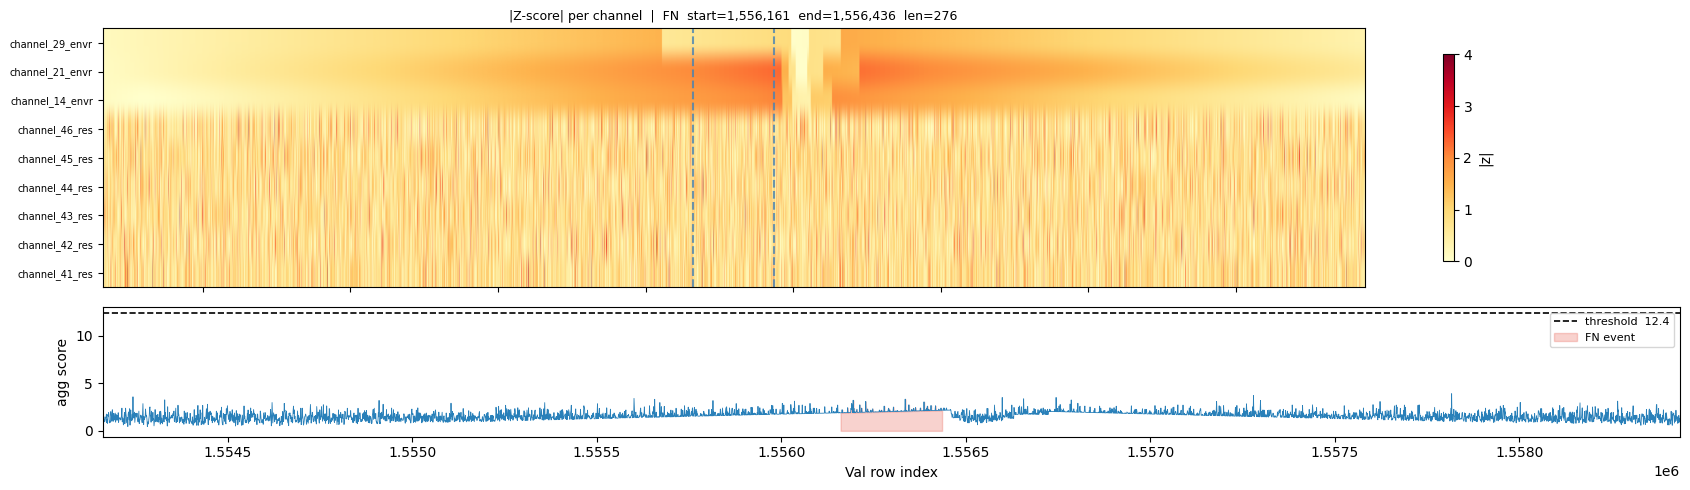

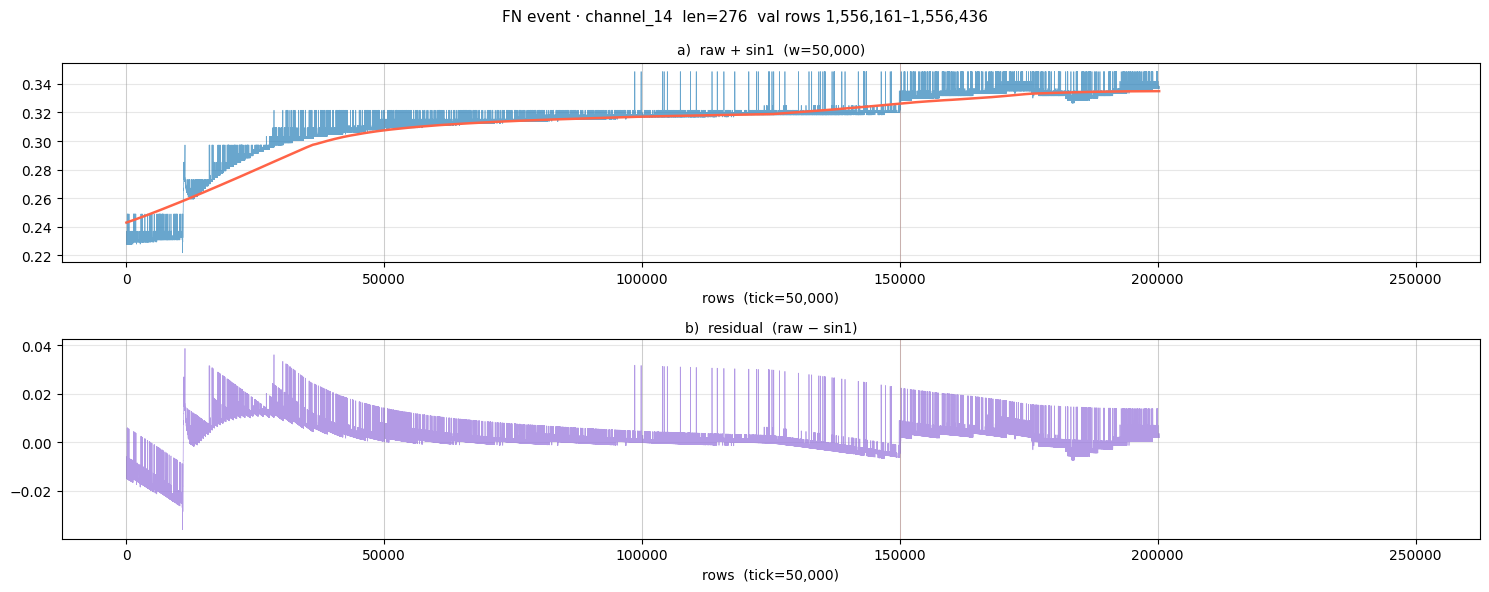

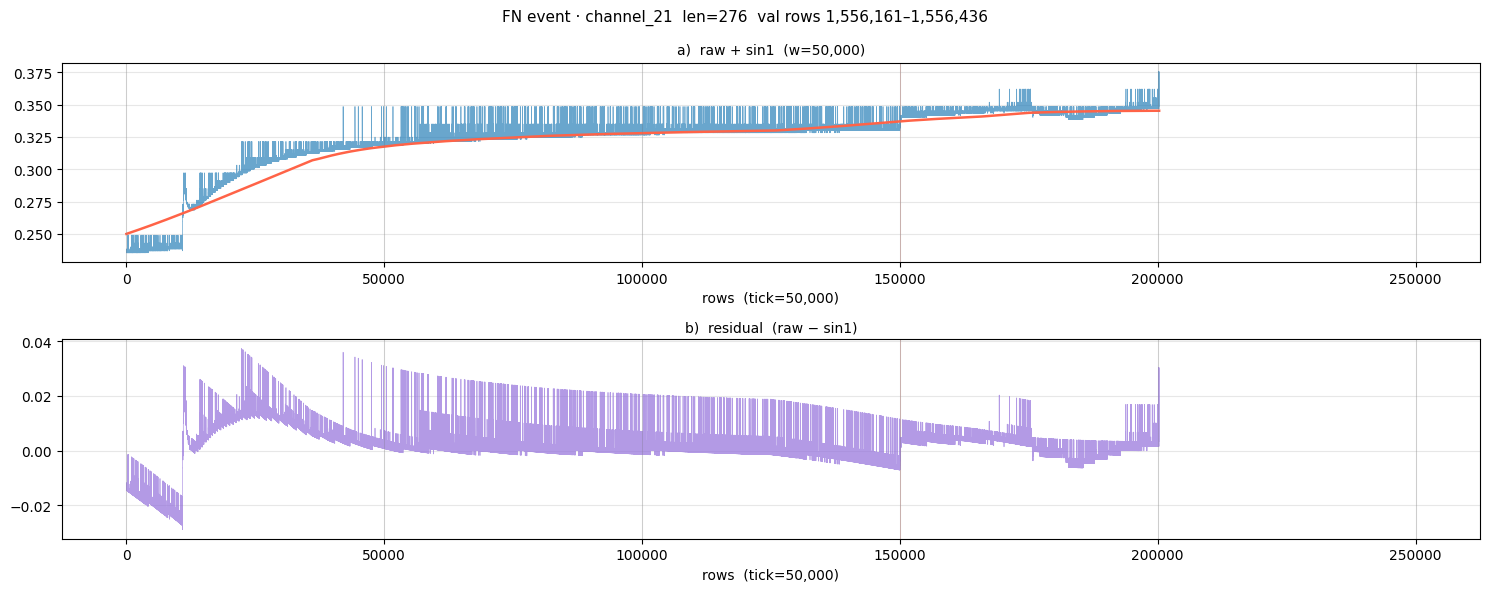

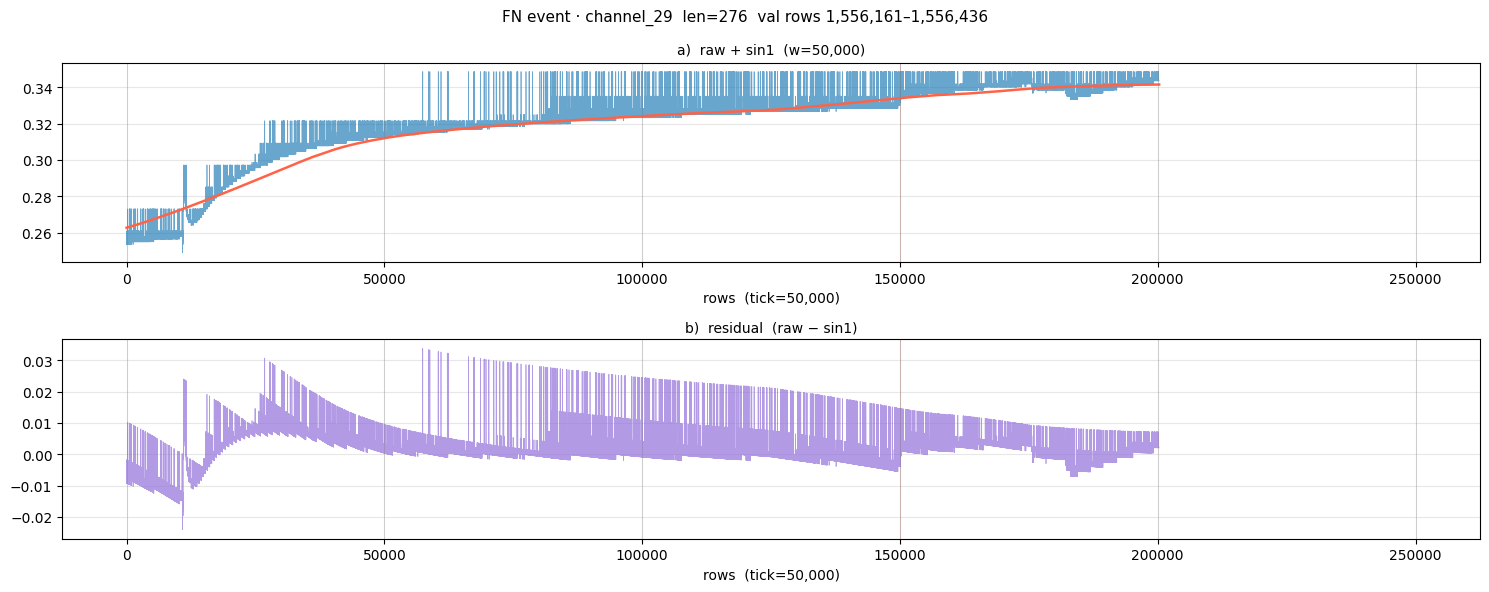


────────────────────────────────────────────────────────────
FN  start=2,009,869  end=2,010,147  len=279


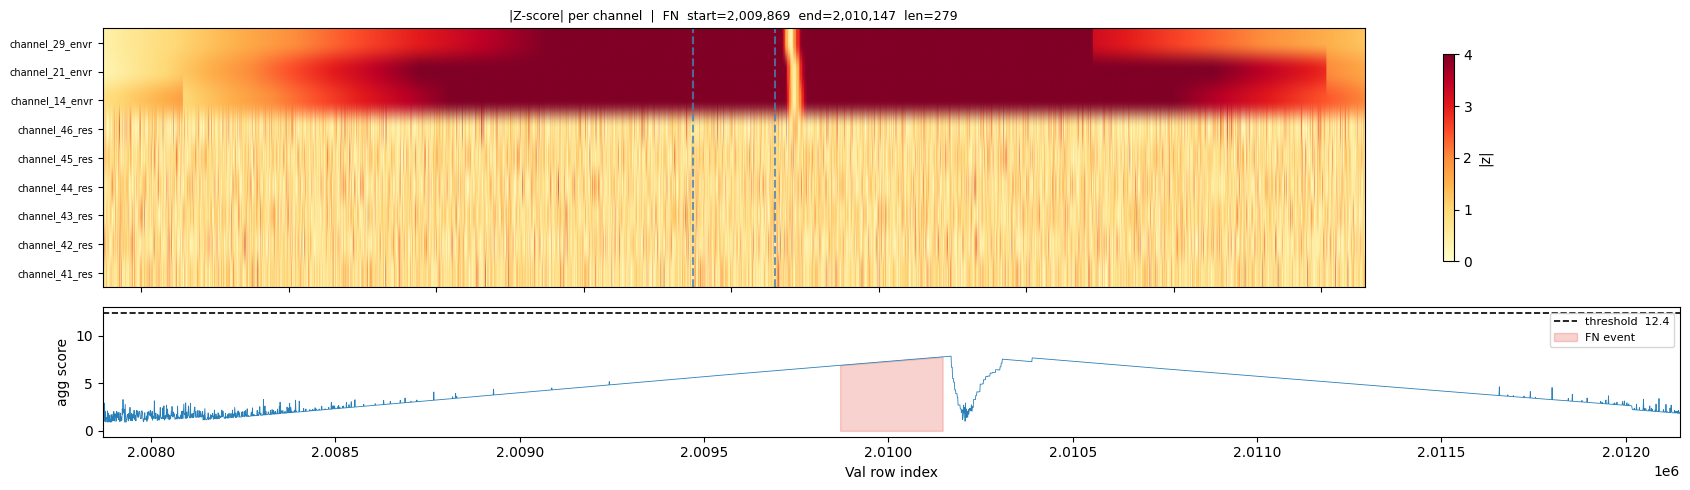

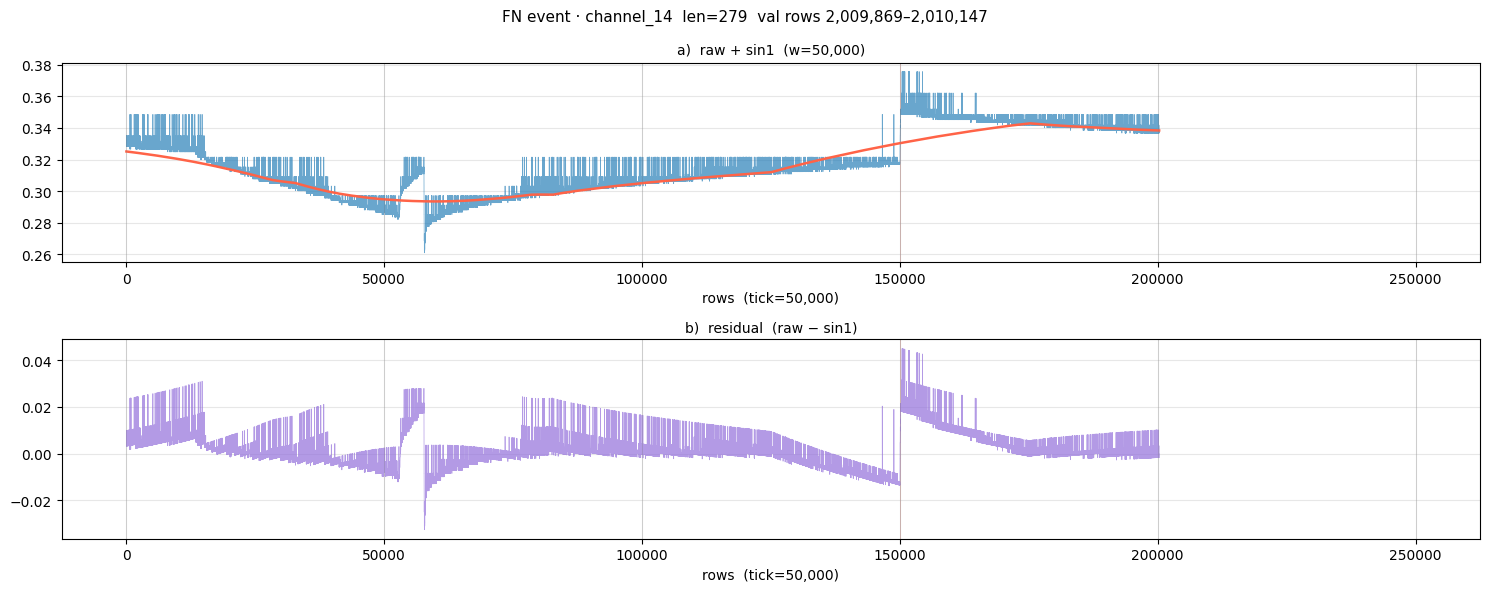

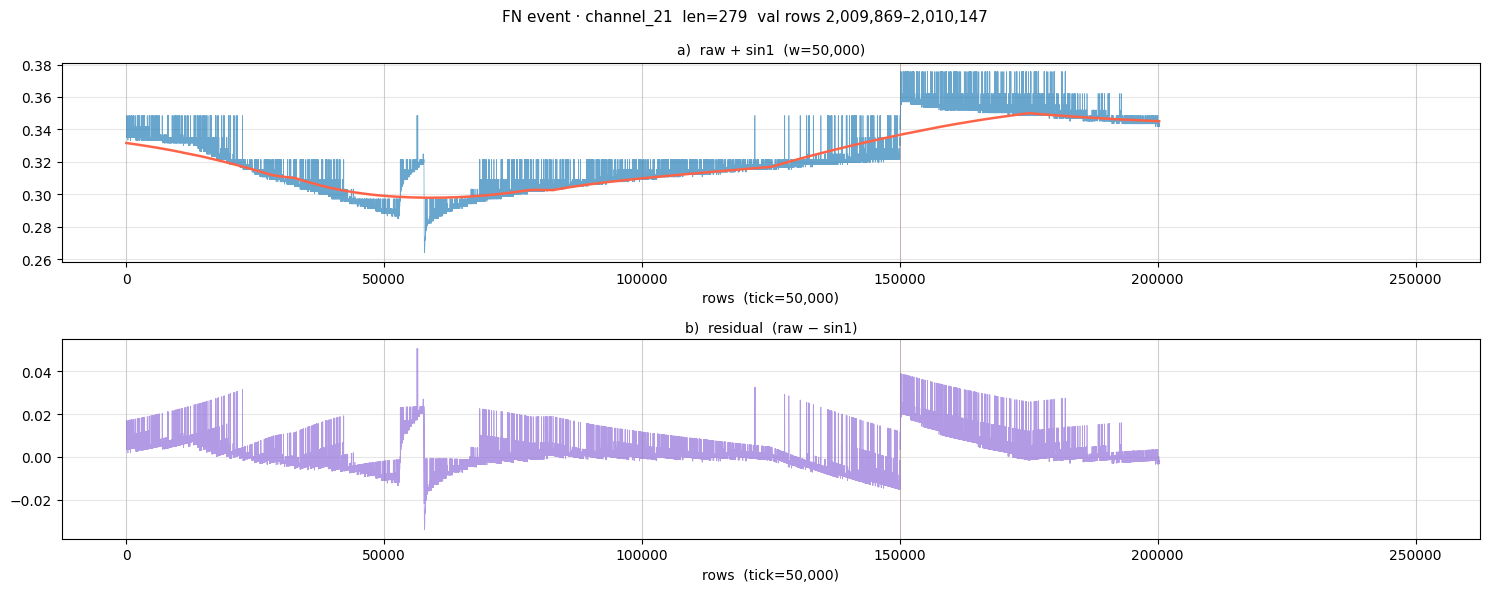

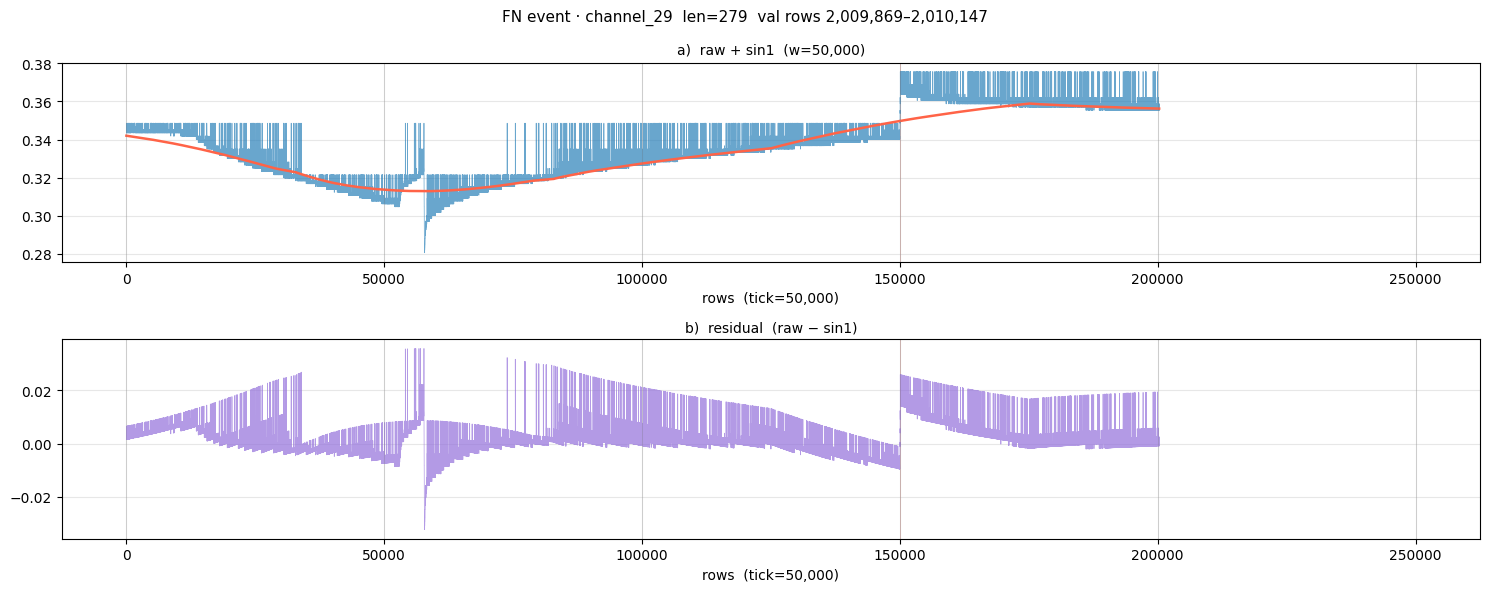


────────────────────────────────────────────────────────────
FN  start=819,541  end=819,876  len=336


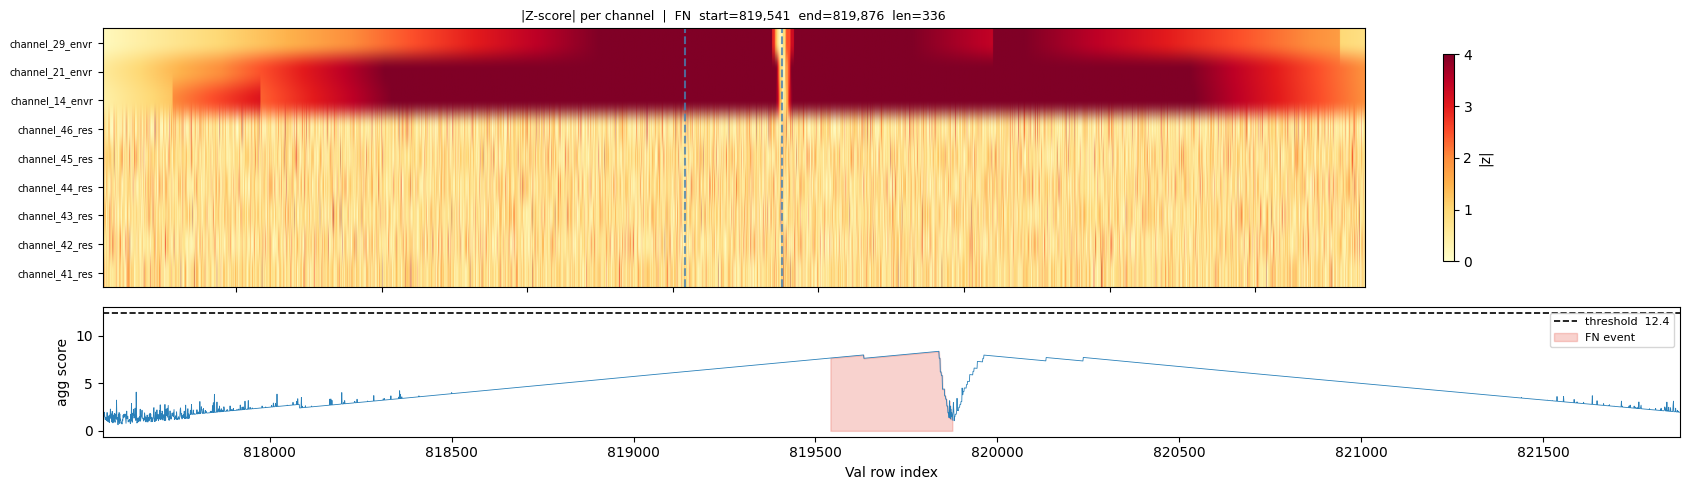

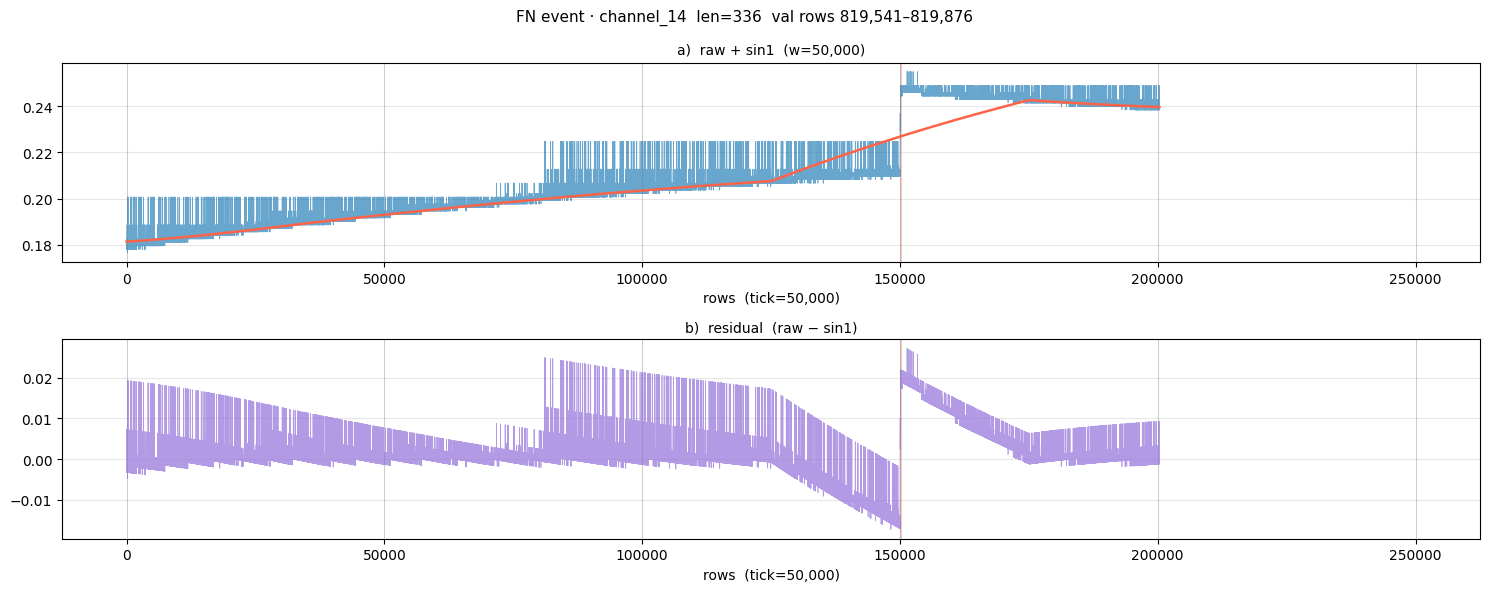

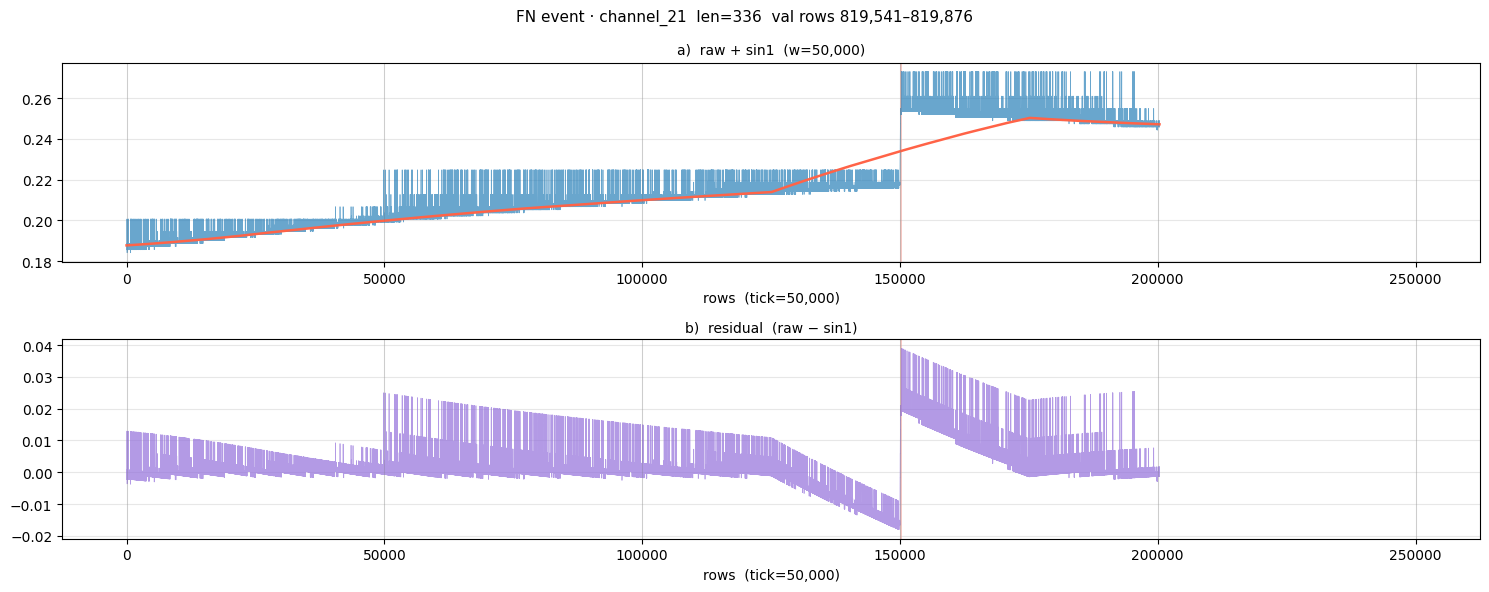

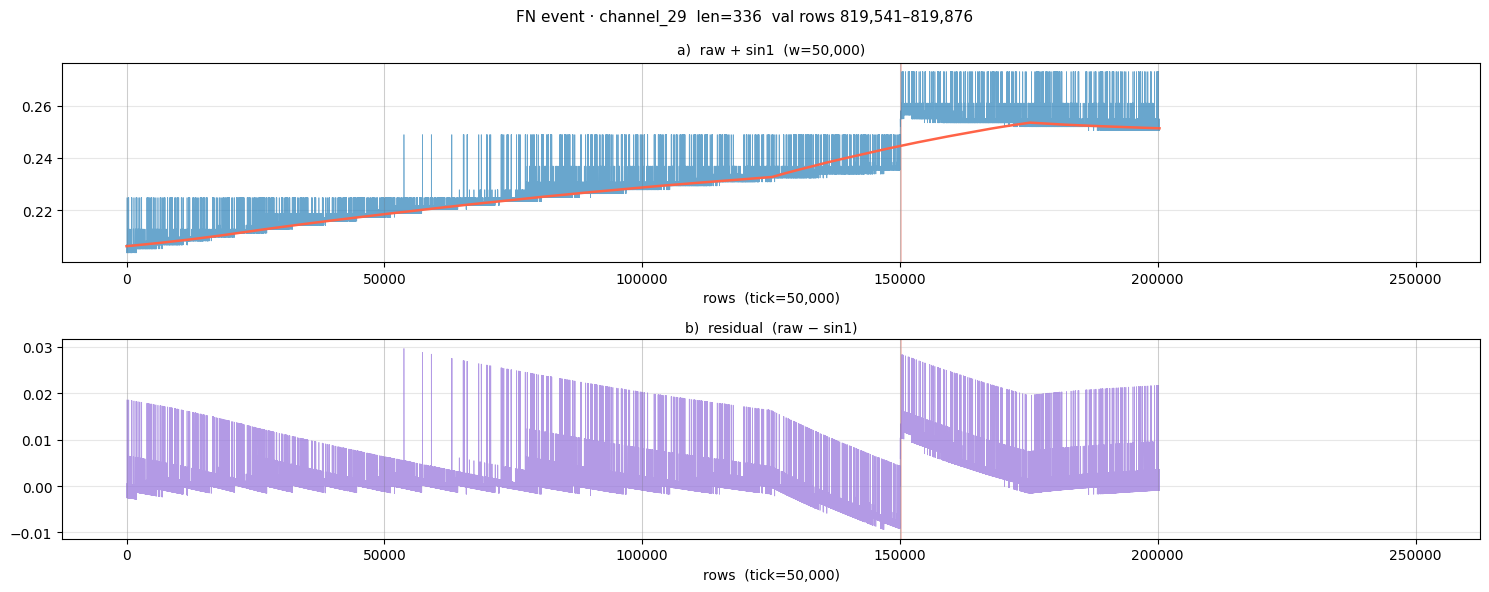


────────────────────────────────────────────────────────────
FN  start=399,395  end=399,763  len=369


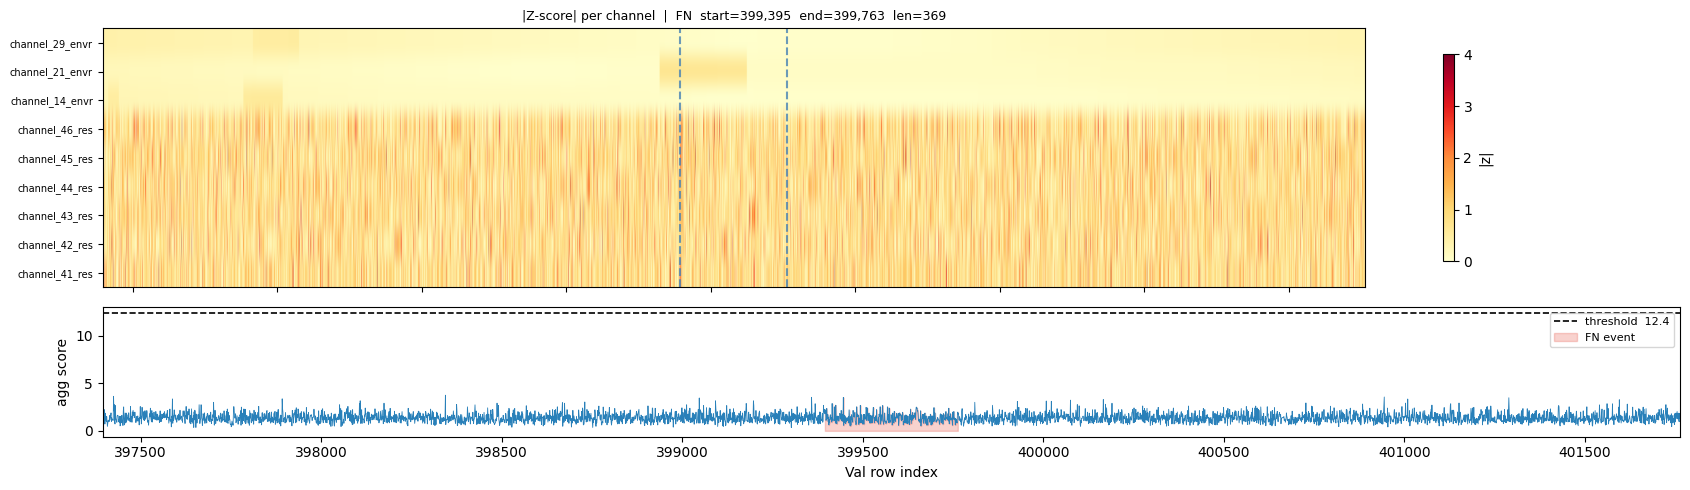

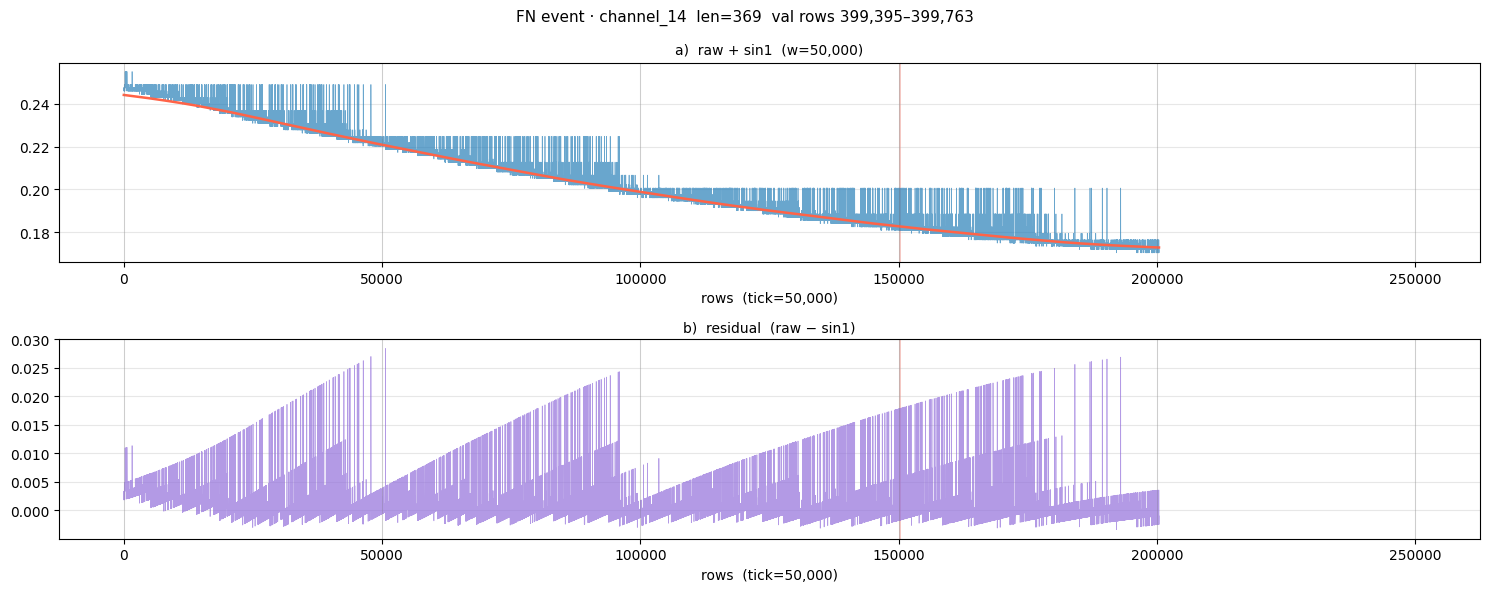

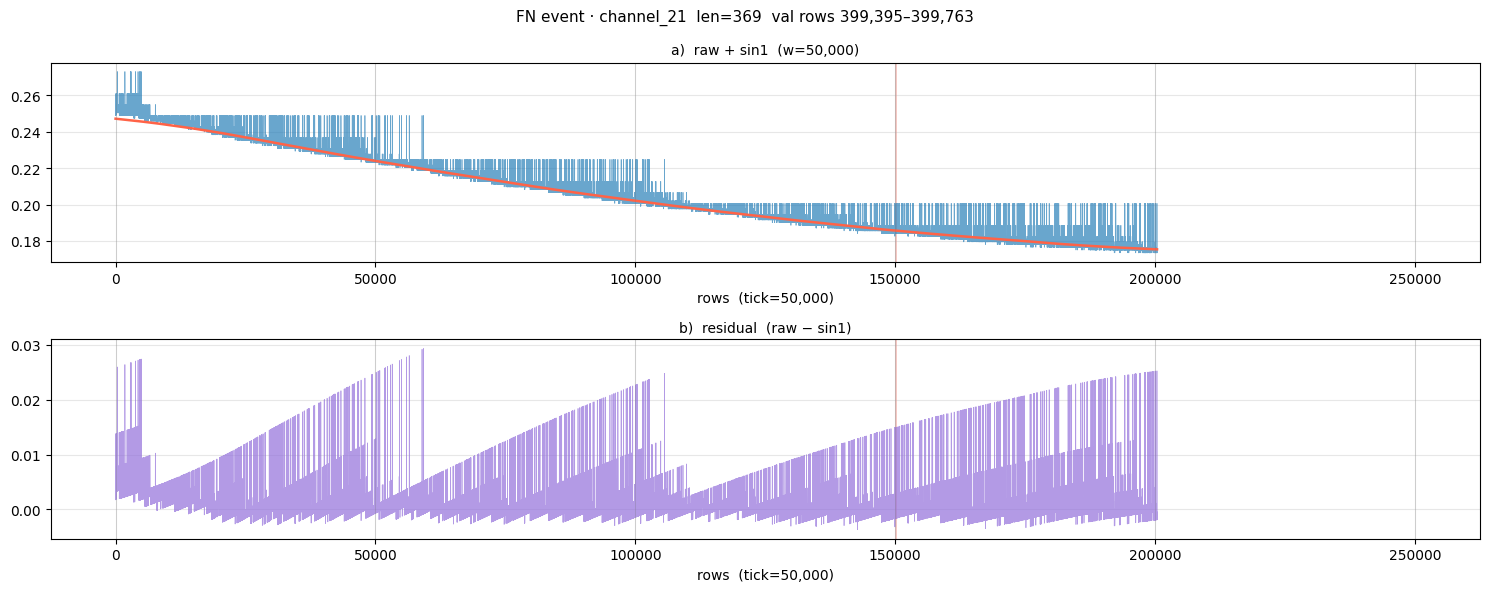

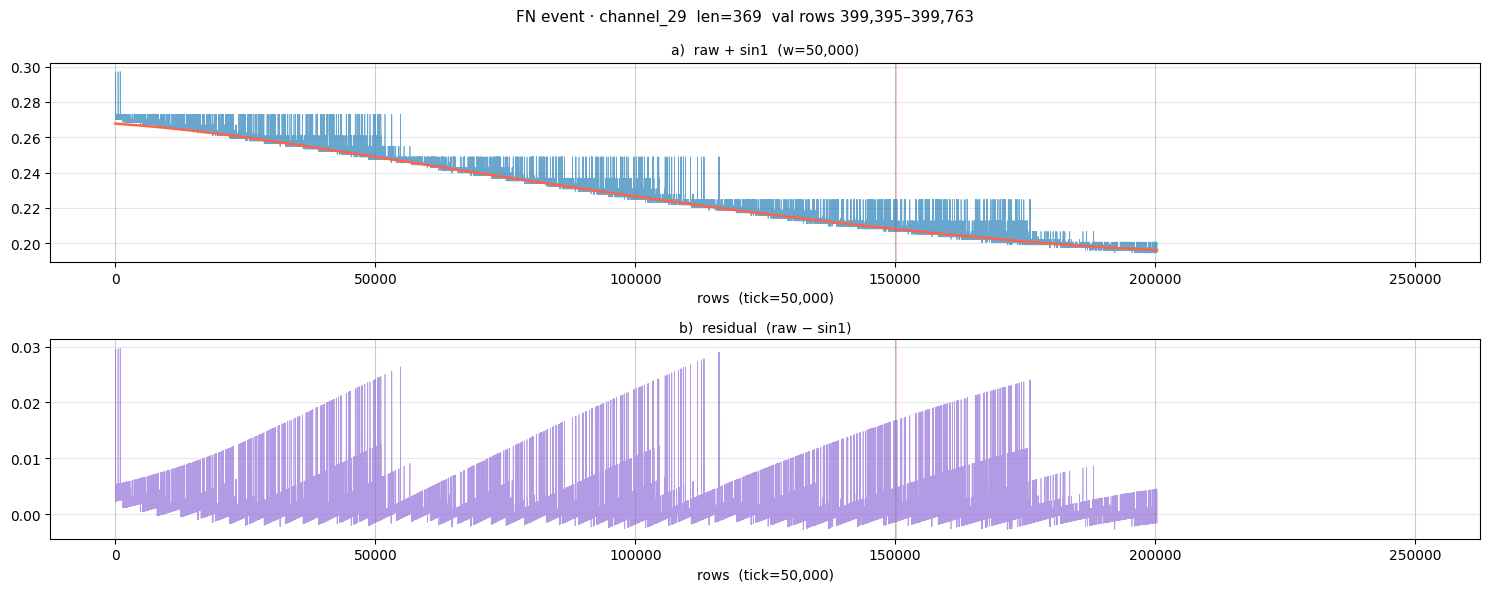


────────────────────────────────────────────────────────────
FN  start=97,133  end=97,726  len=594


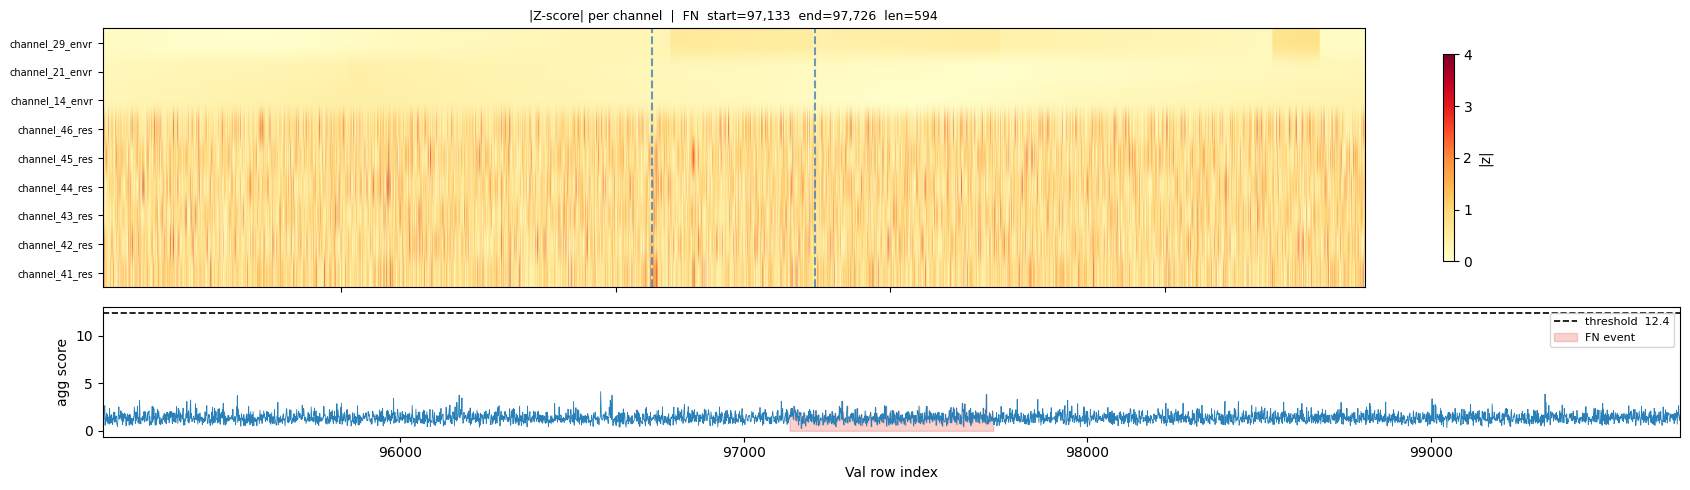

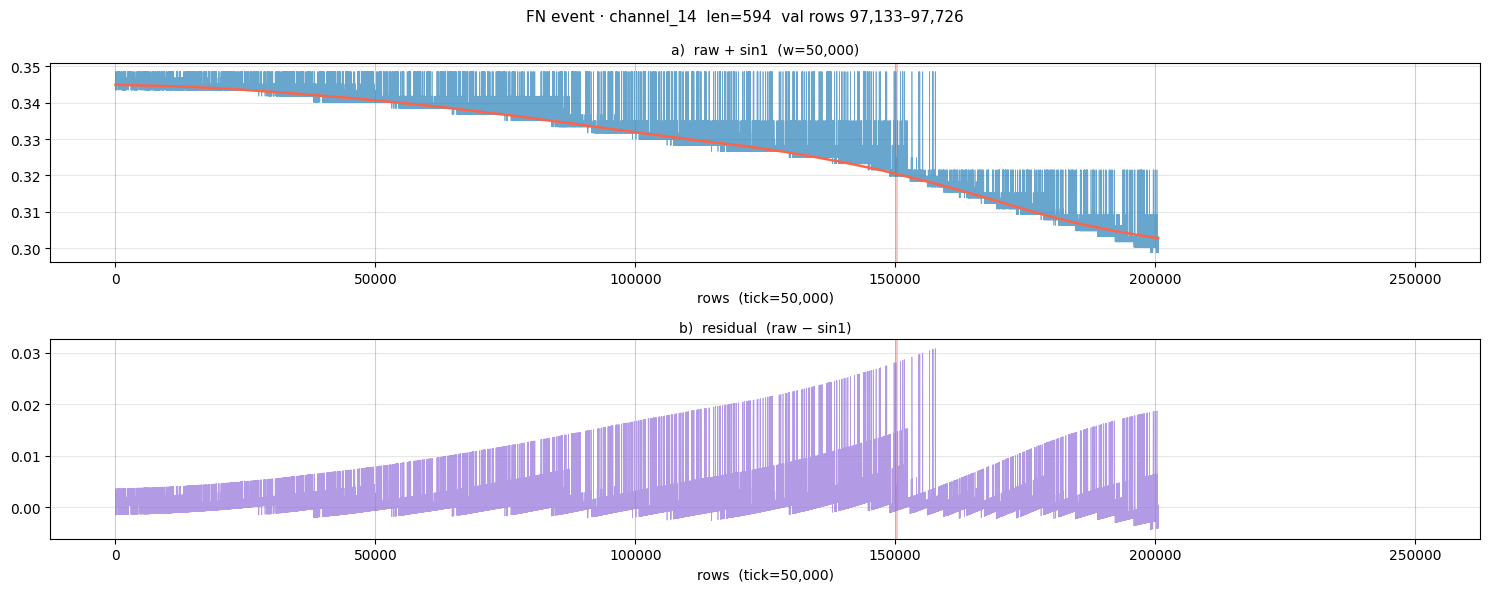

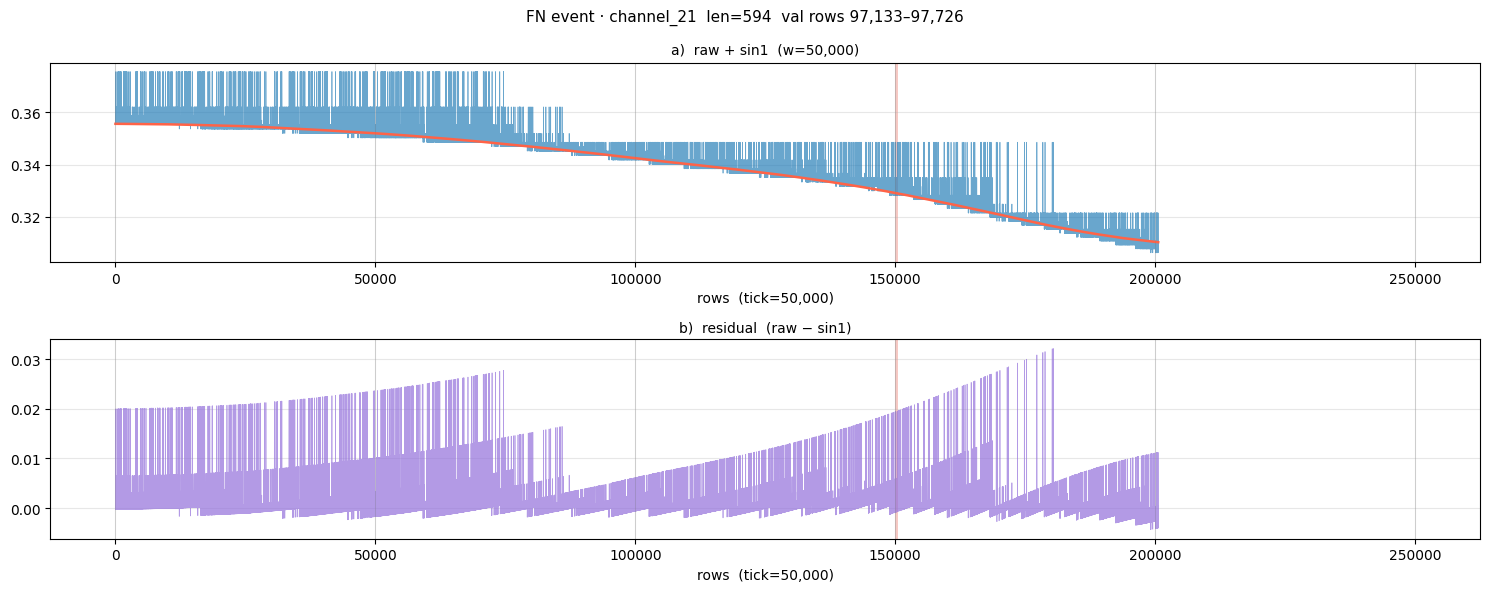

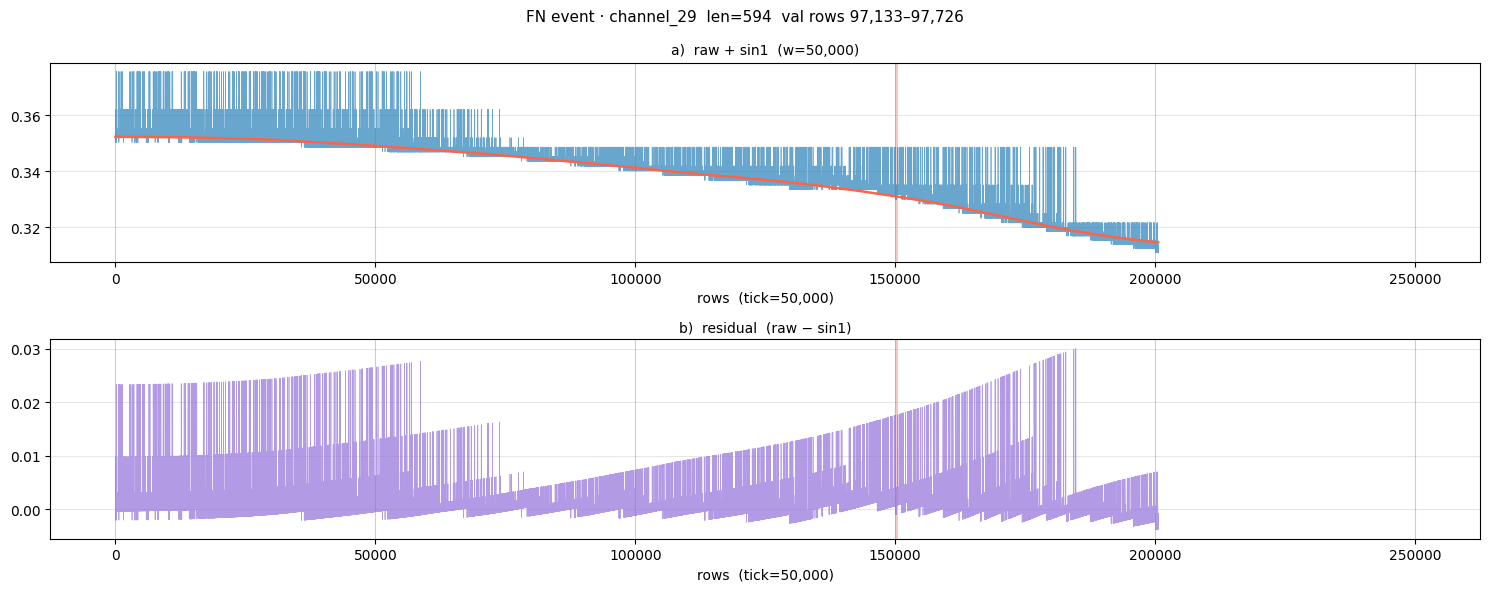


────────────────────────────────────────────────────────────
FN  start=1,912,819  end=1,913,928  len=1,110


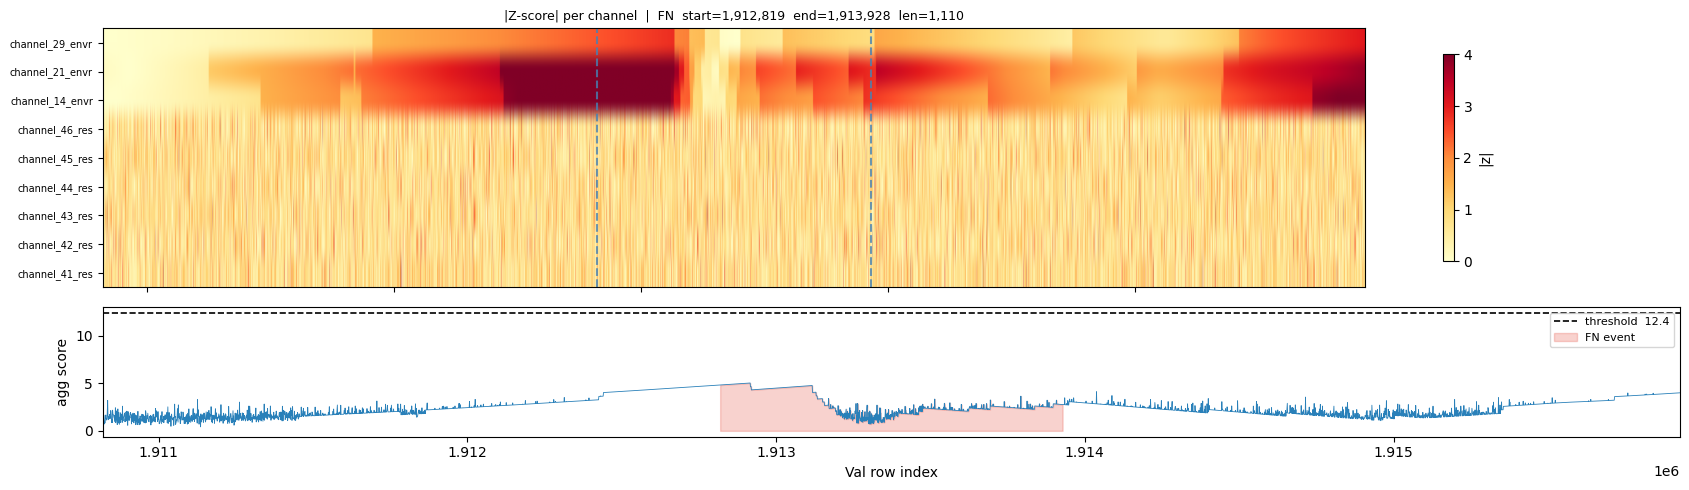

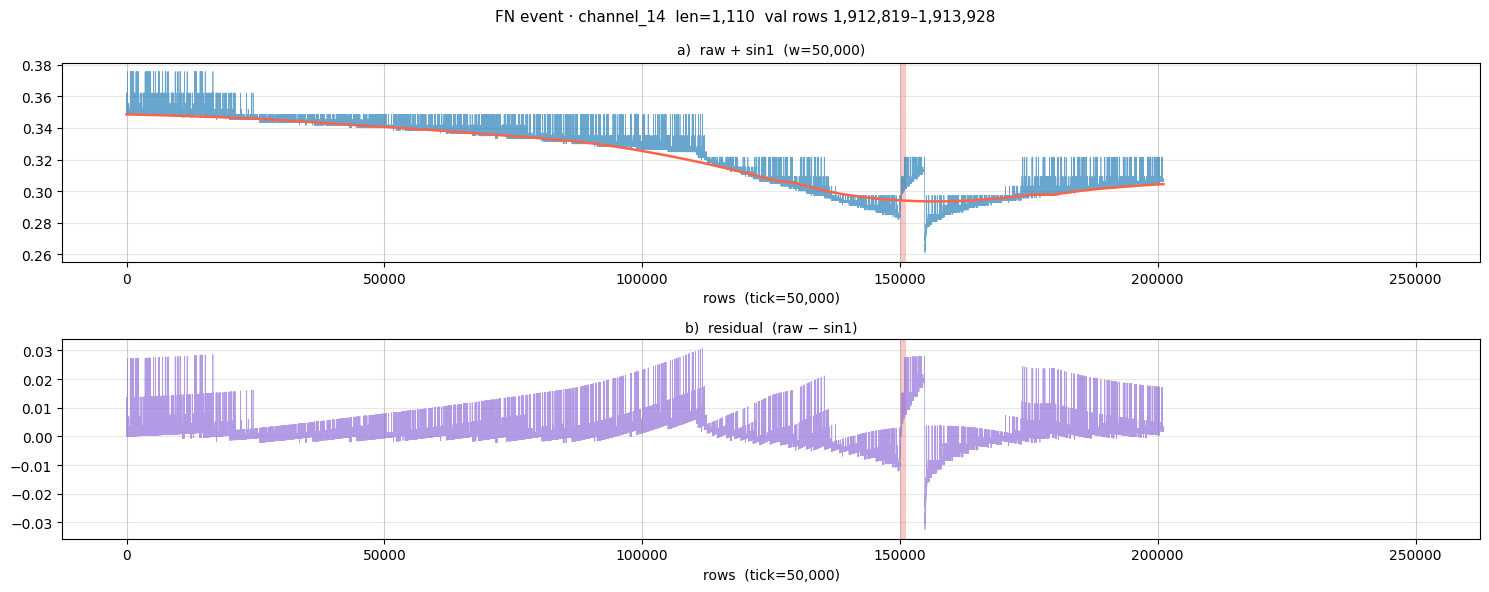

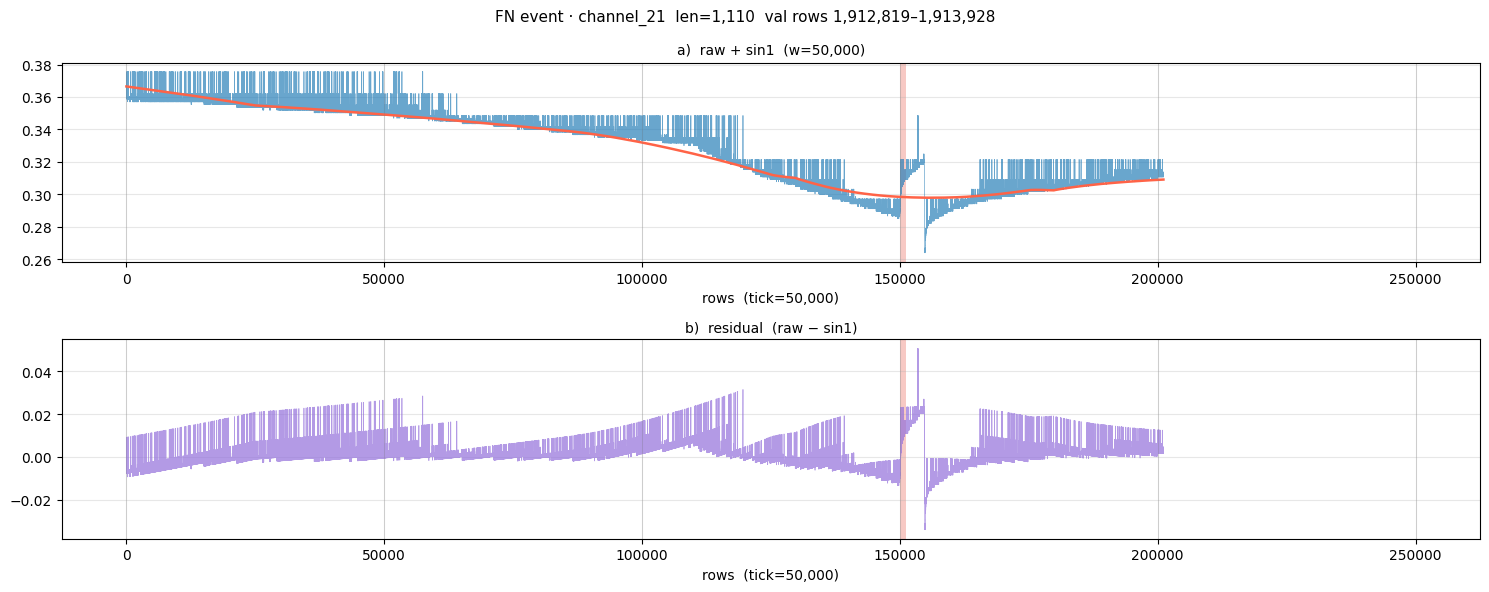

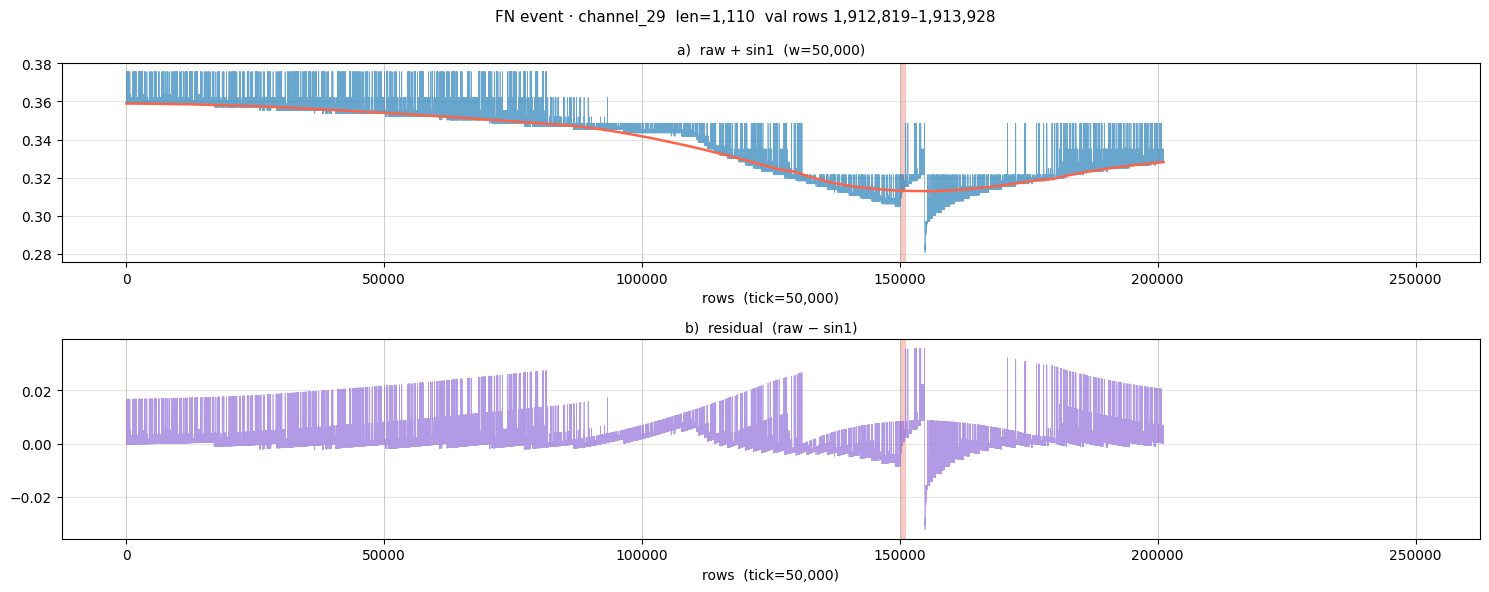


────────────────────────────────────────────────────────────
FN  start=2,069,274  end=2,070,523  len=1,250


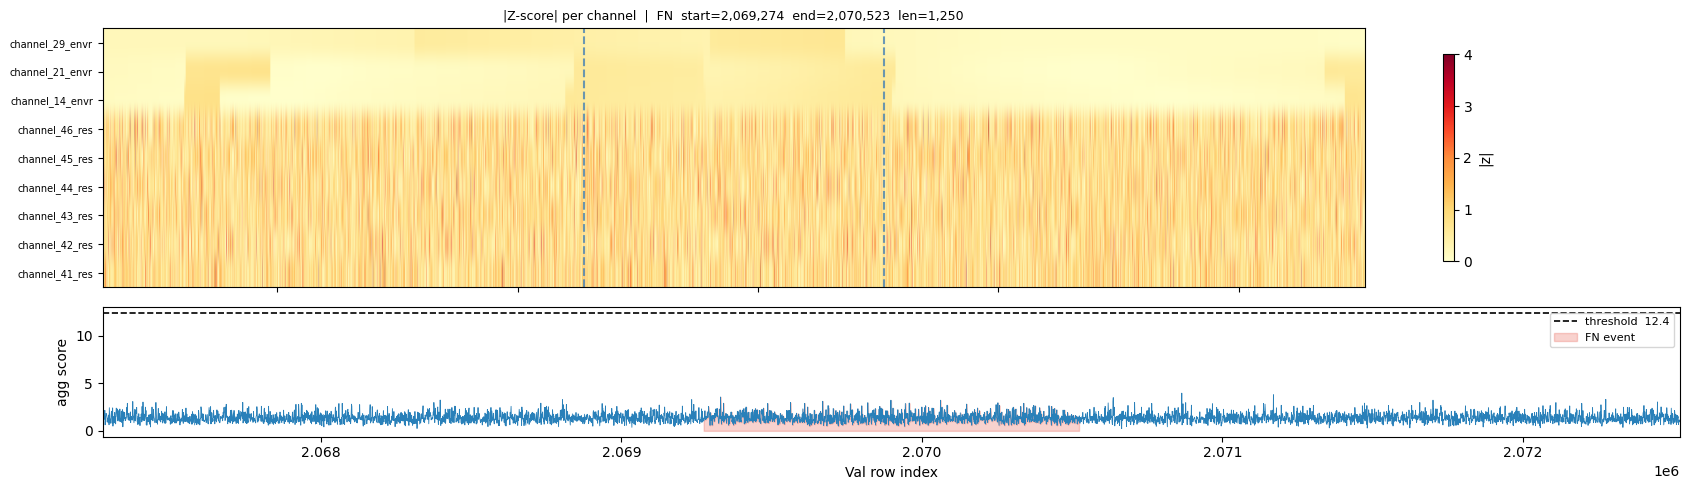

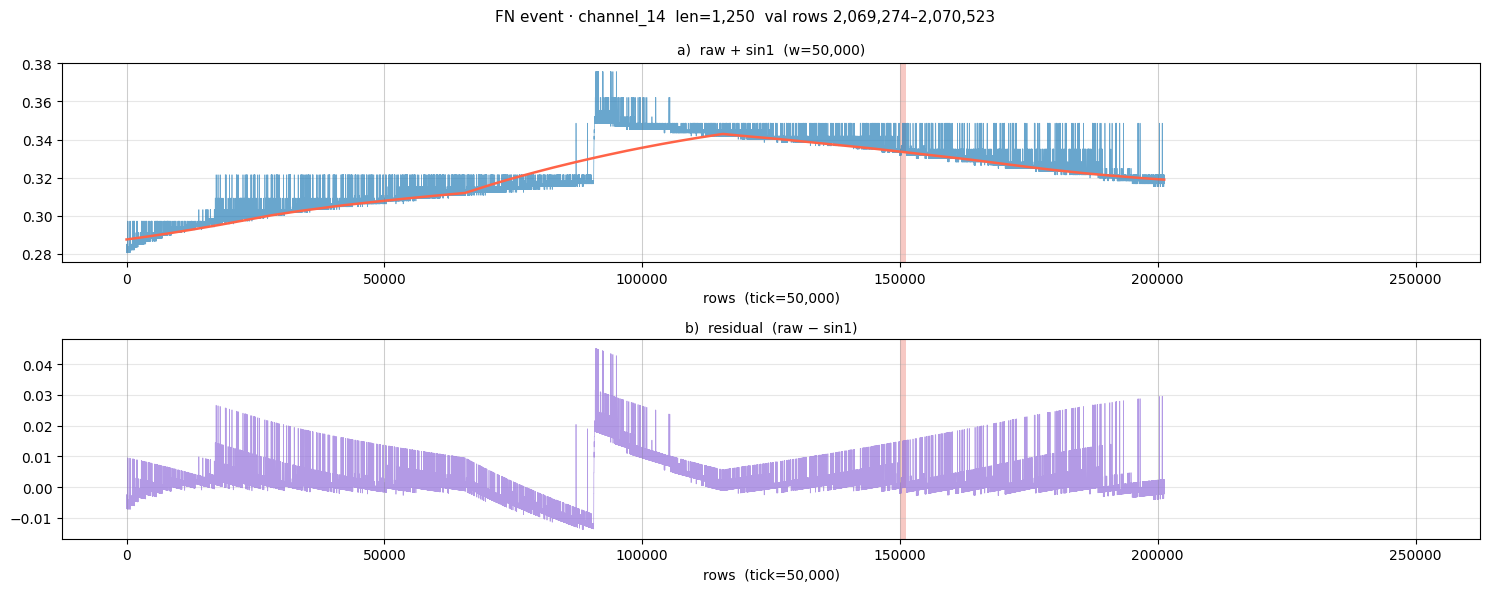

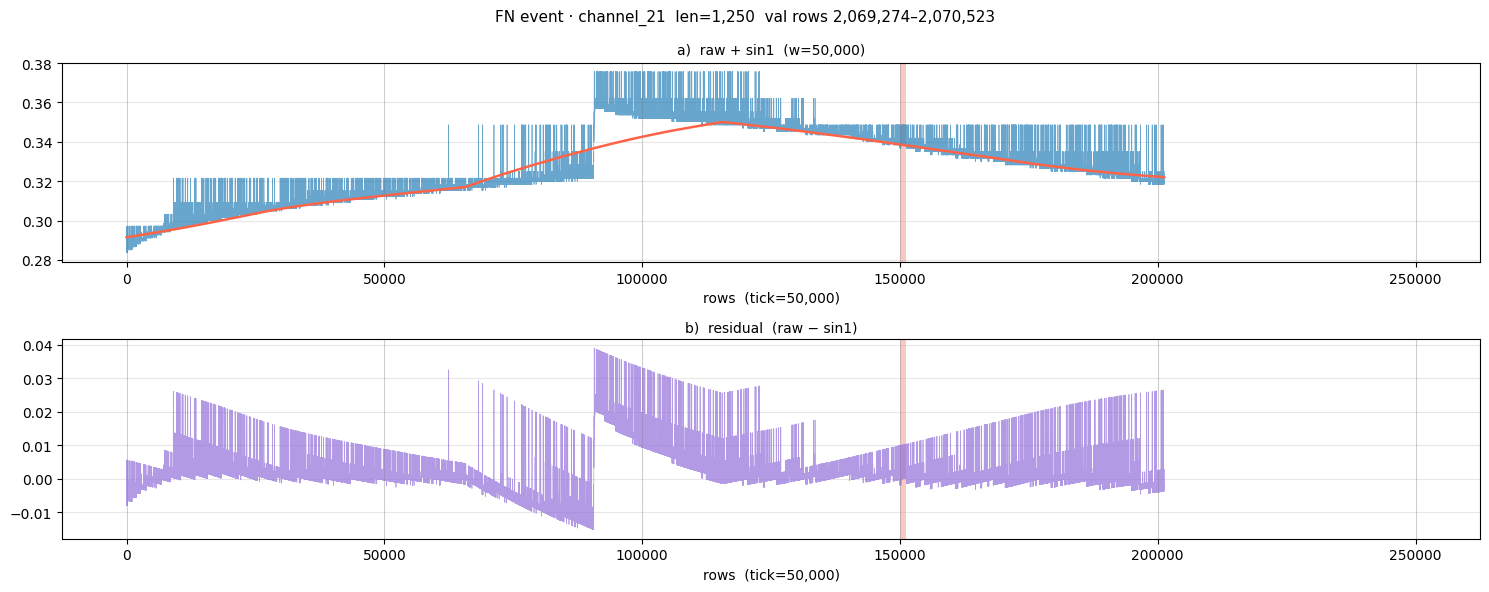

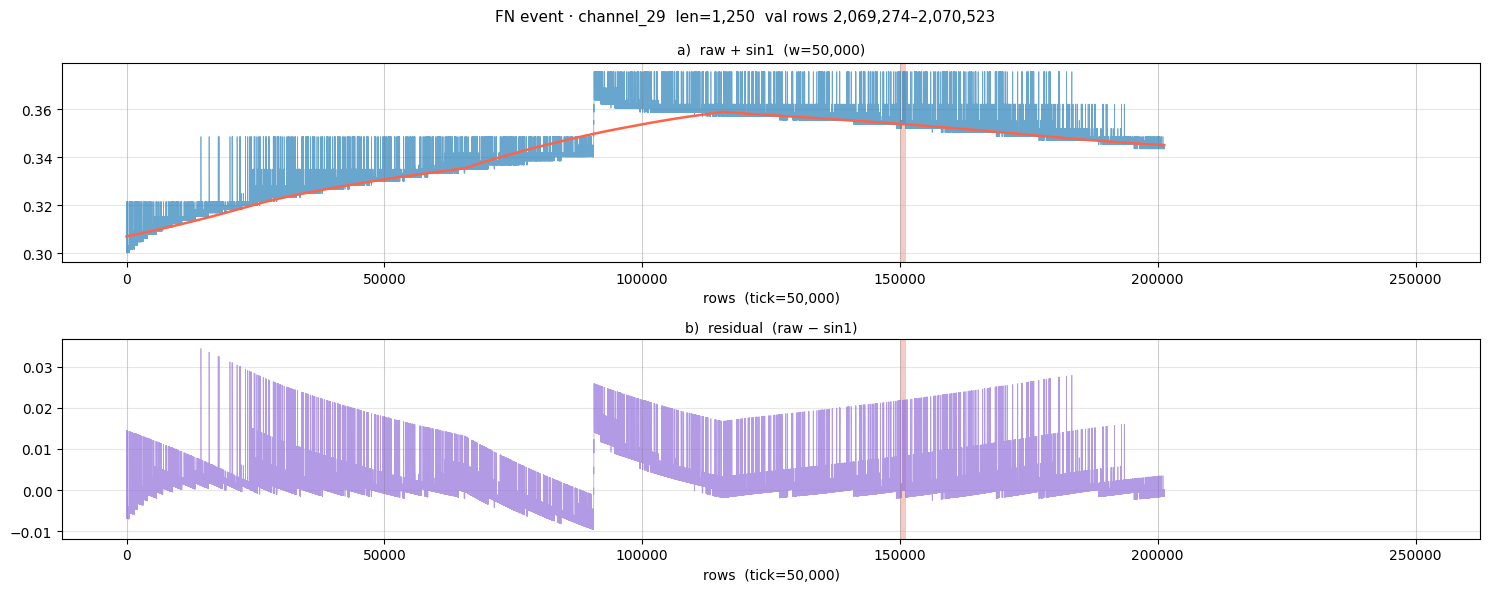


────────────────────────────────────────────────────────────
FN  start=1,573,916  end=1,575,670  len=1,755


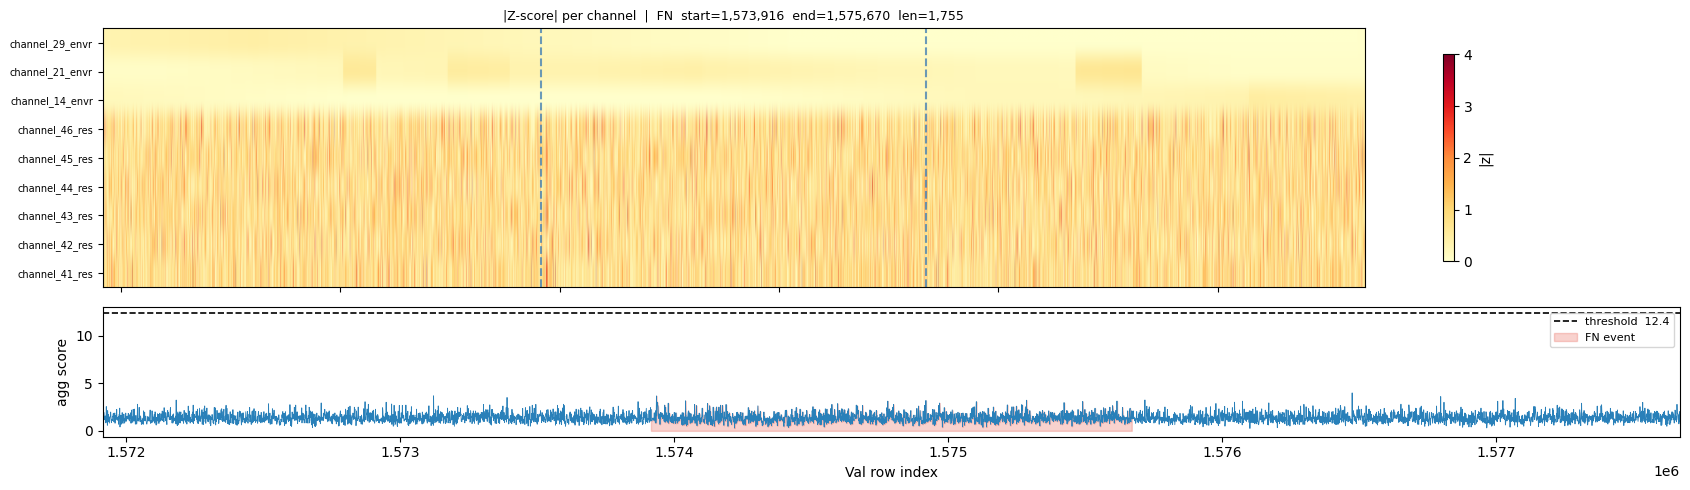

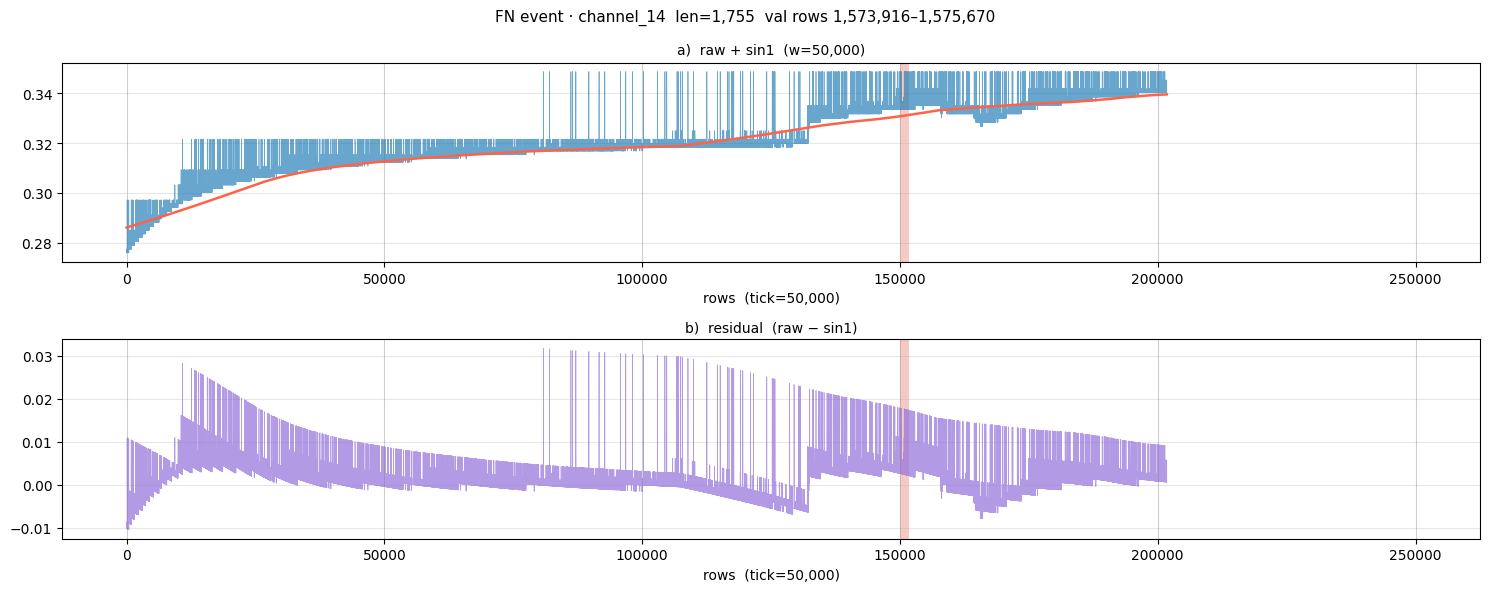

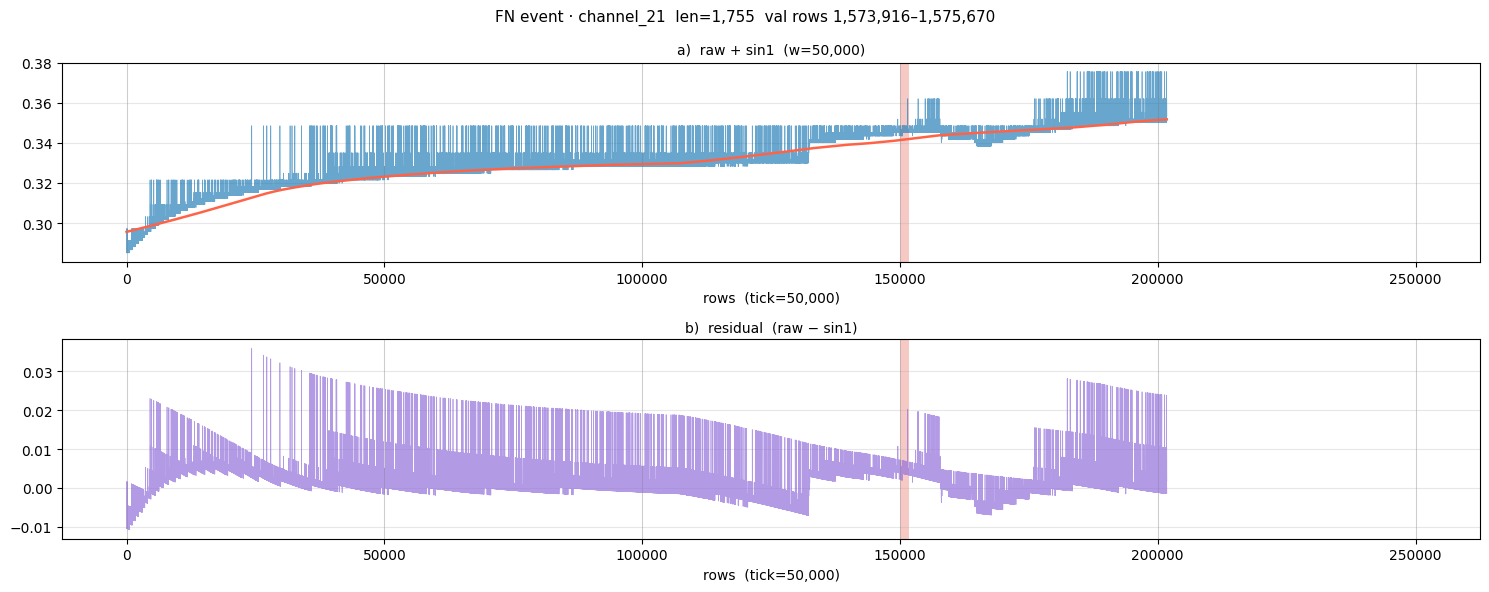

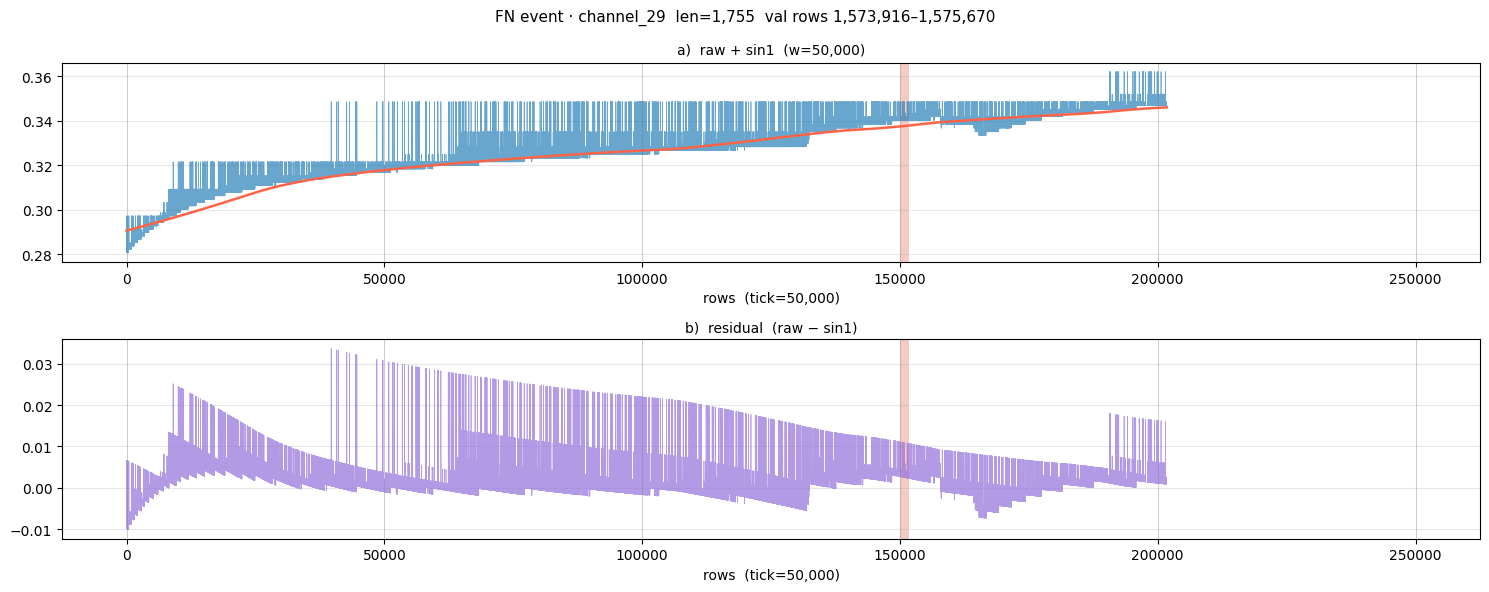


────────────────────────────────────────────────────────────
FN  start=1,342,475  end=1,344,310  len=1,836


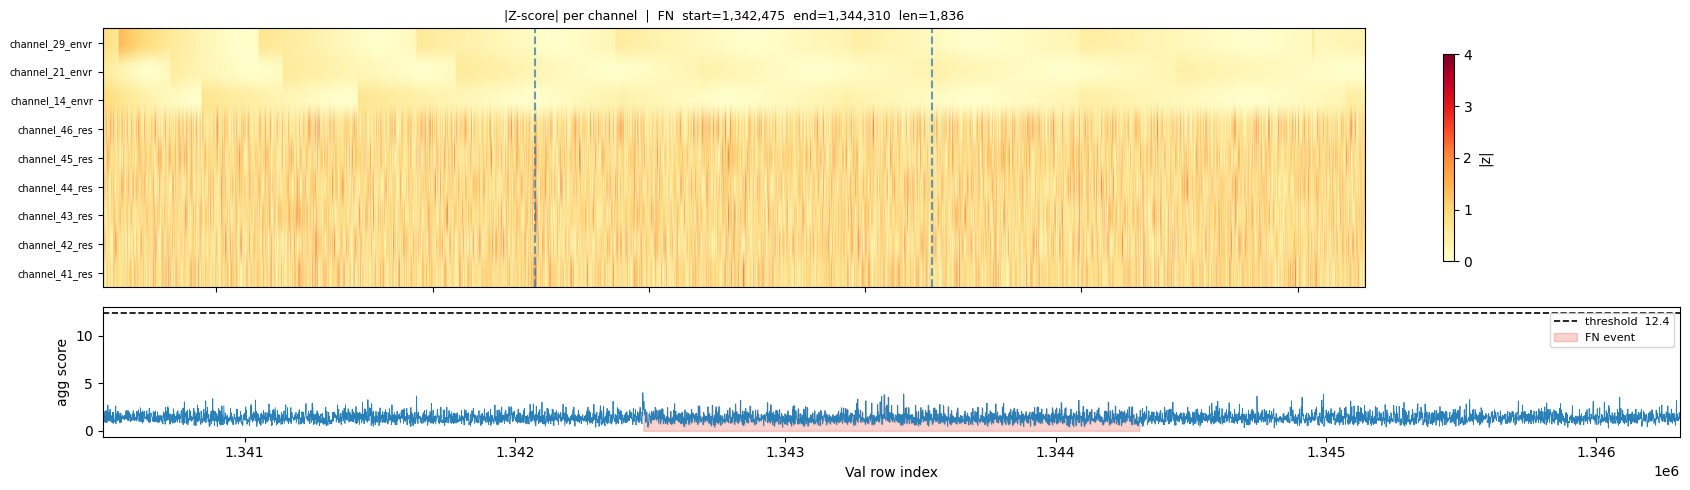

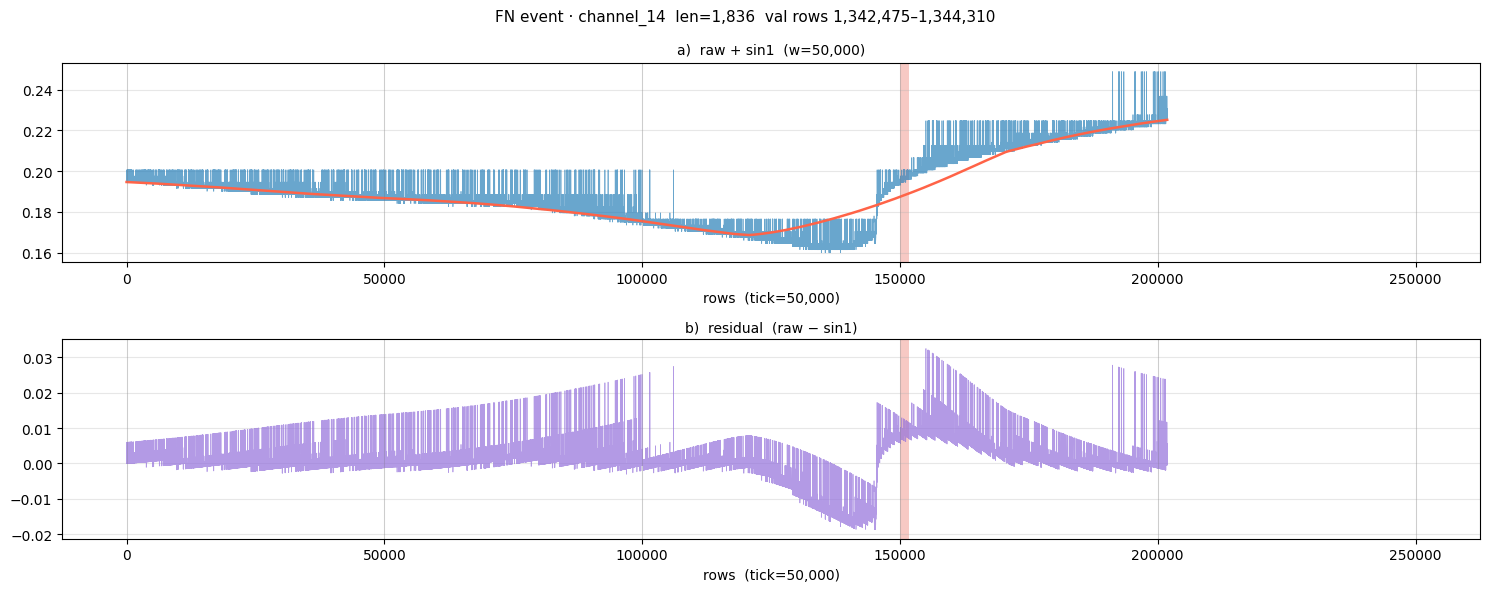

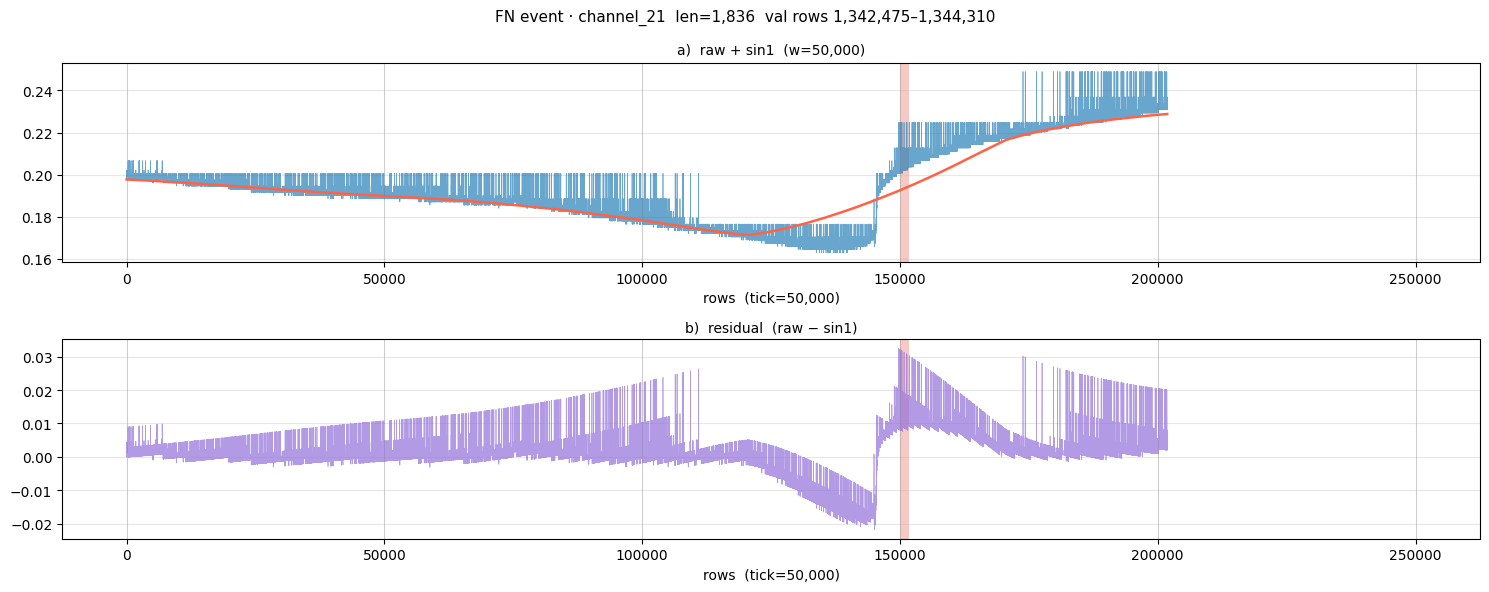

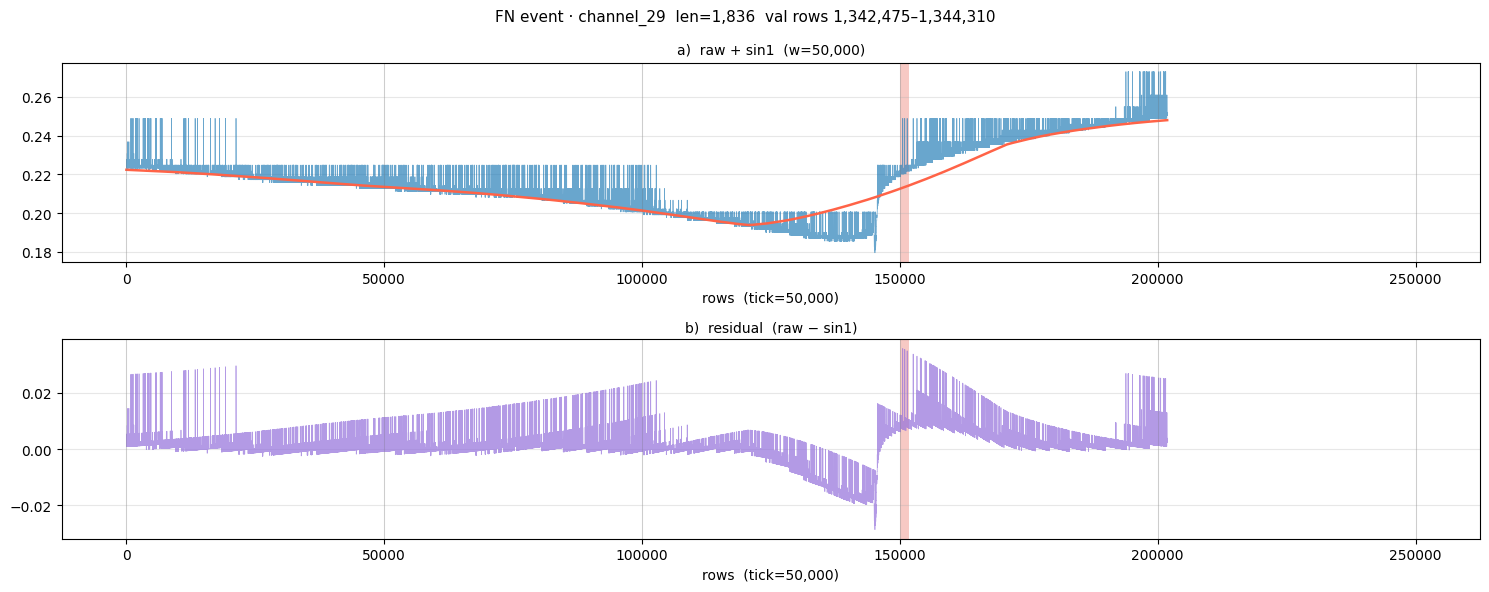


────────────────────────────────────────────────────────────
FN  start=1,337,362  end=1,339,200  len=1,839


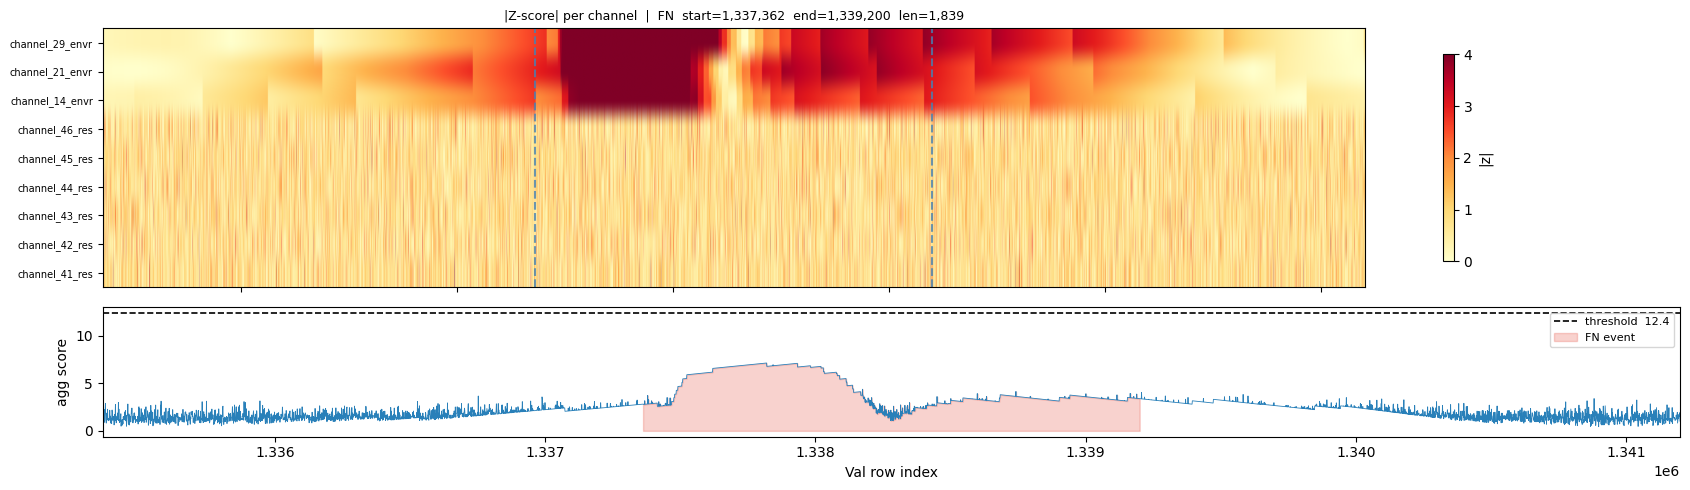

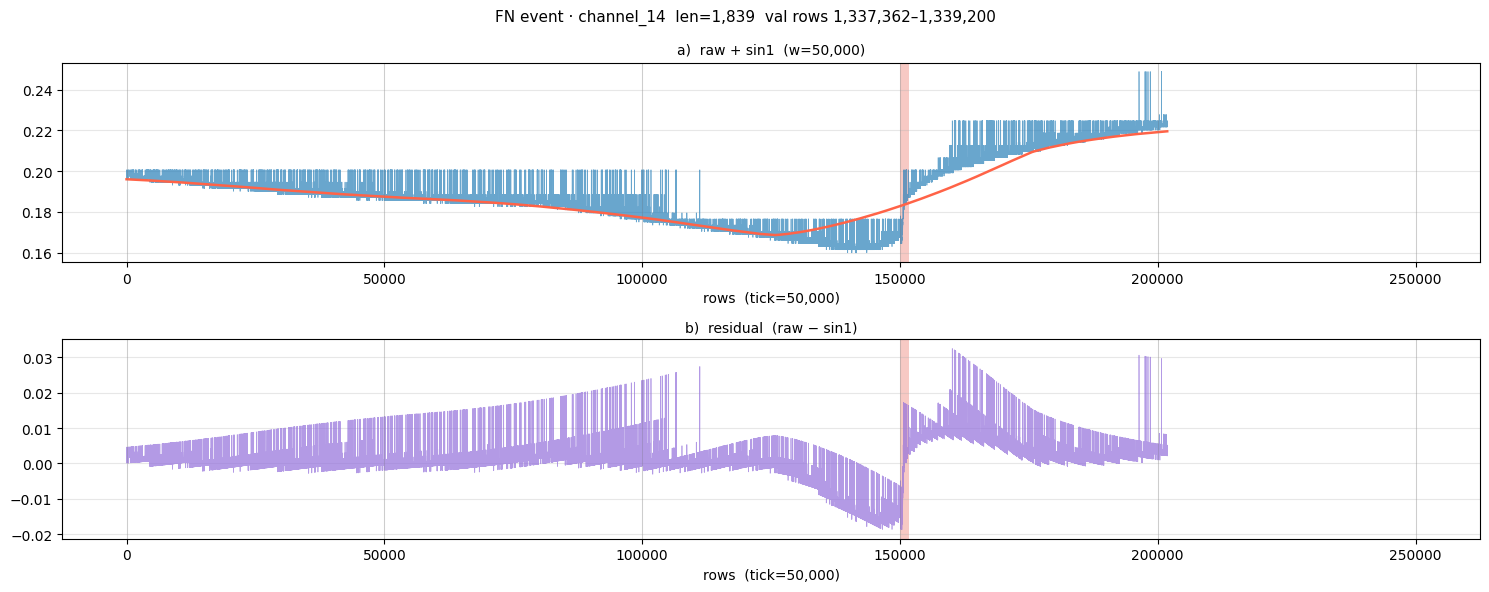

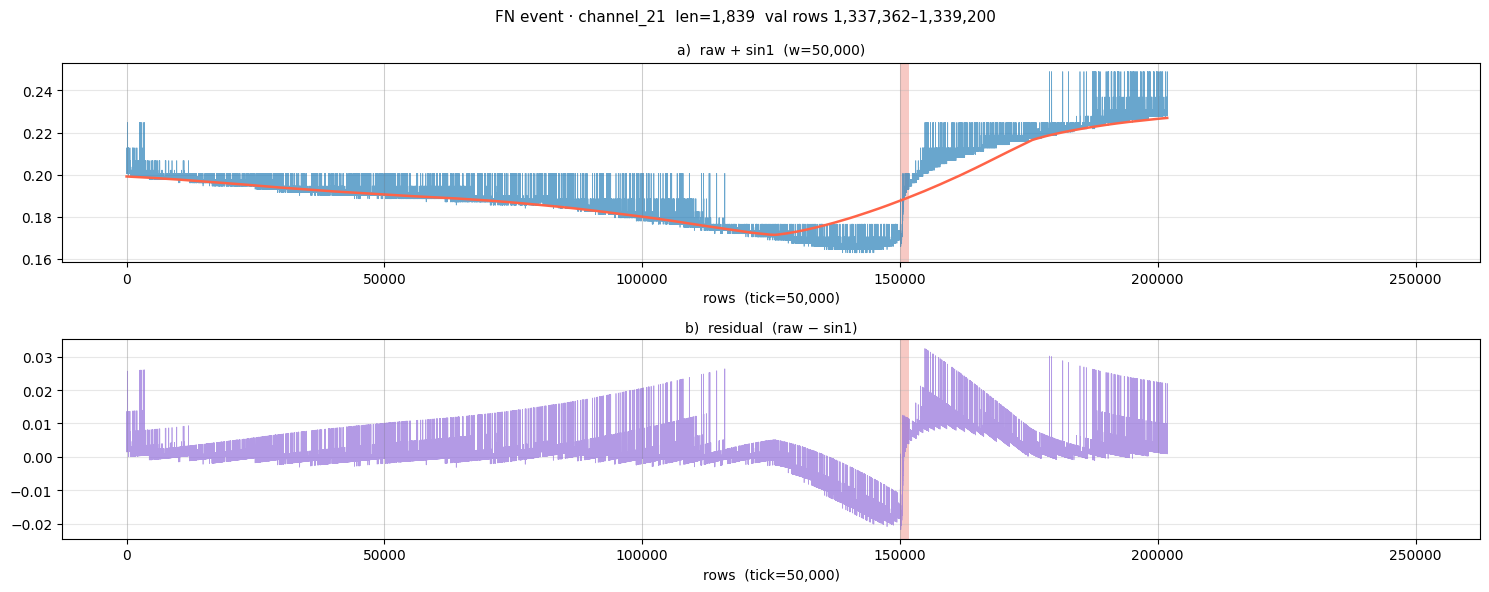

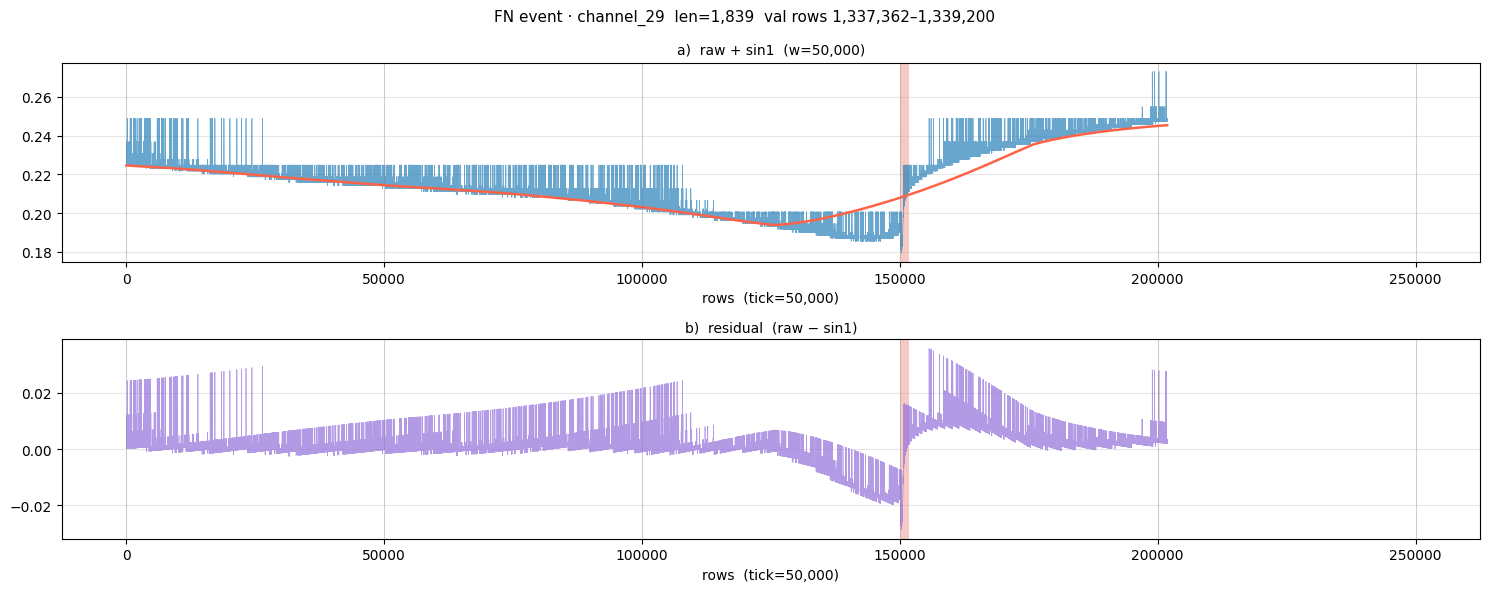


────────────────────────────────────────────────────────────
FN  start=548,497  end=552,855  len=4,359


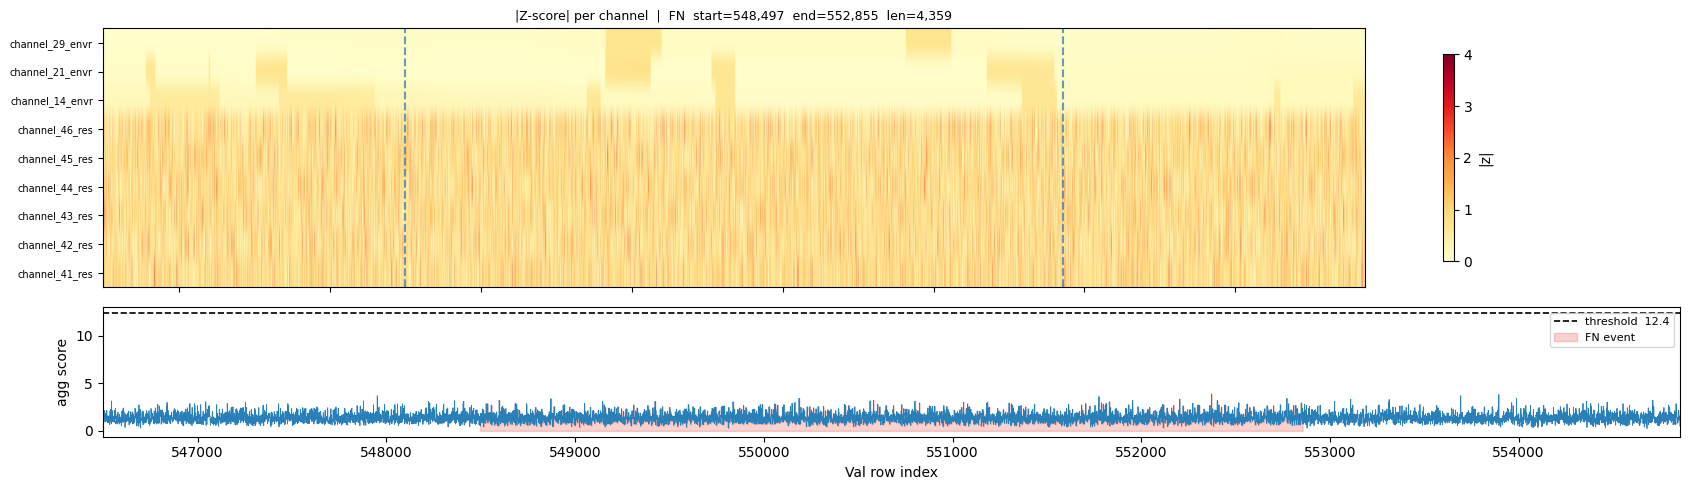

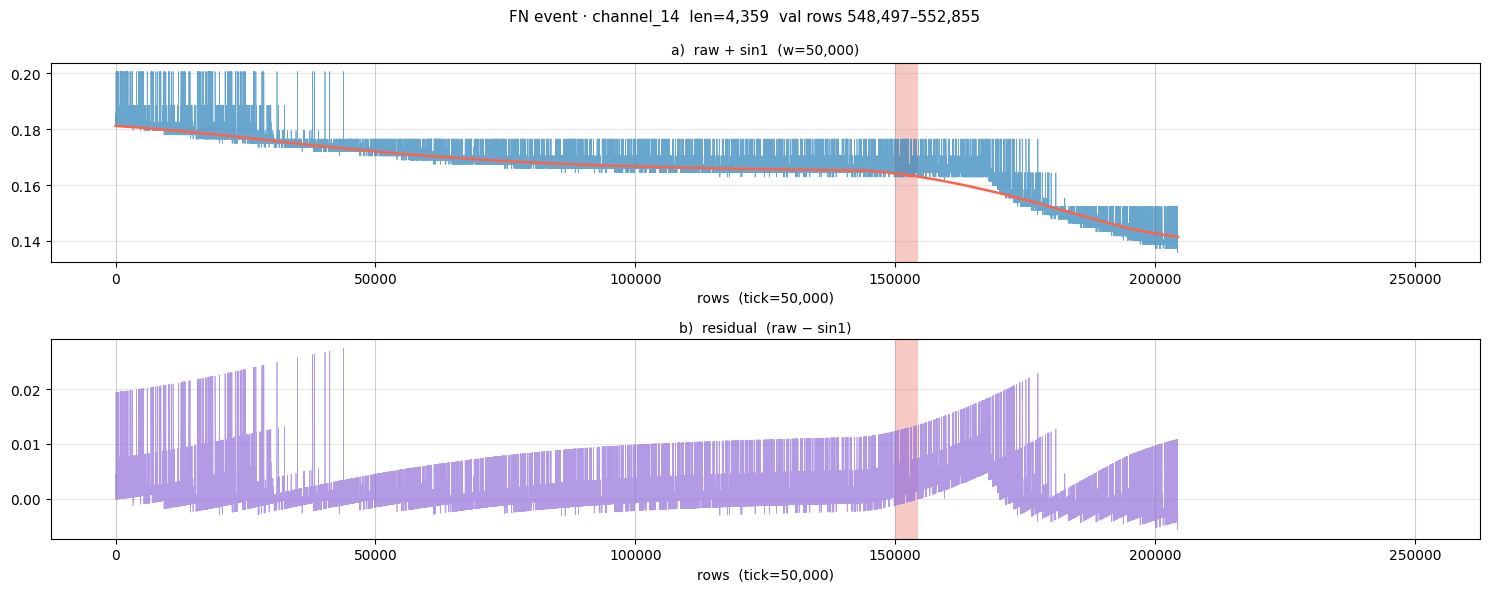

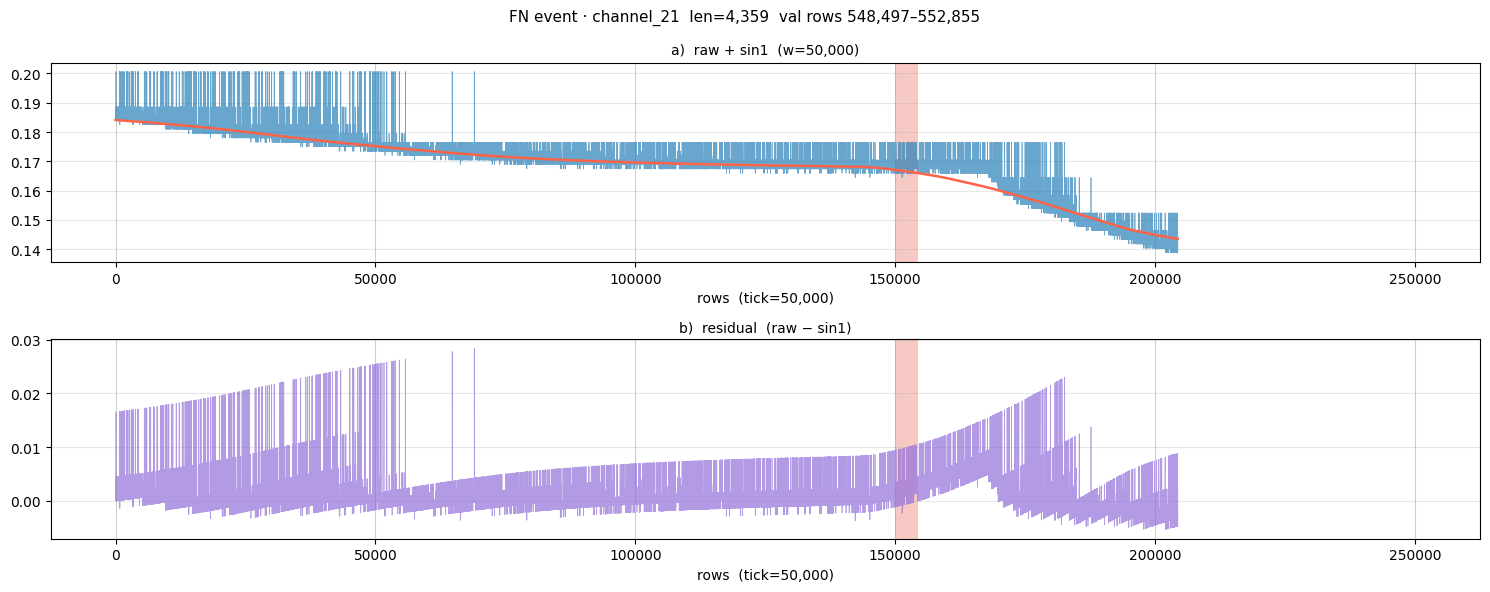

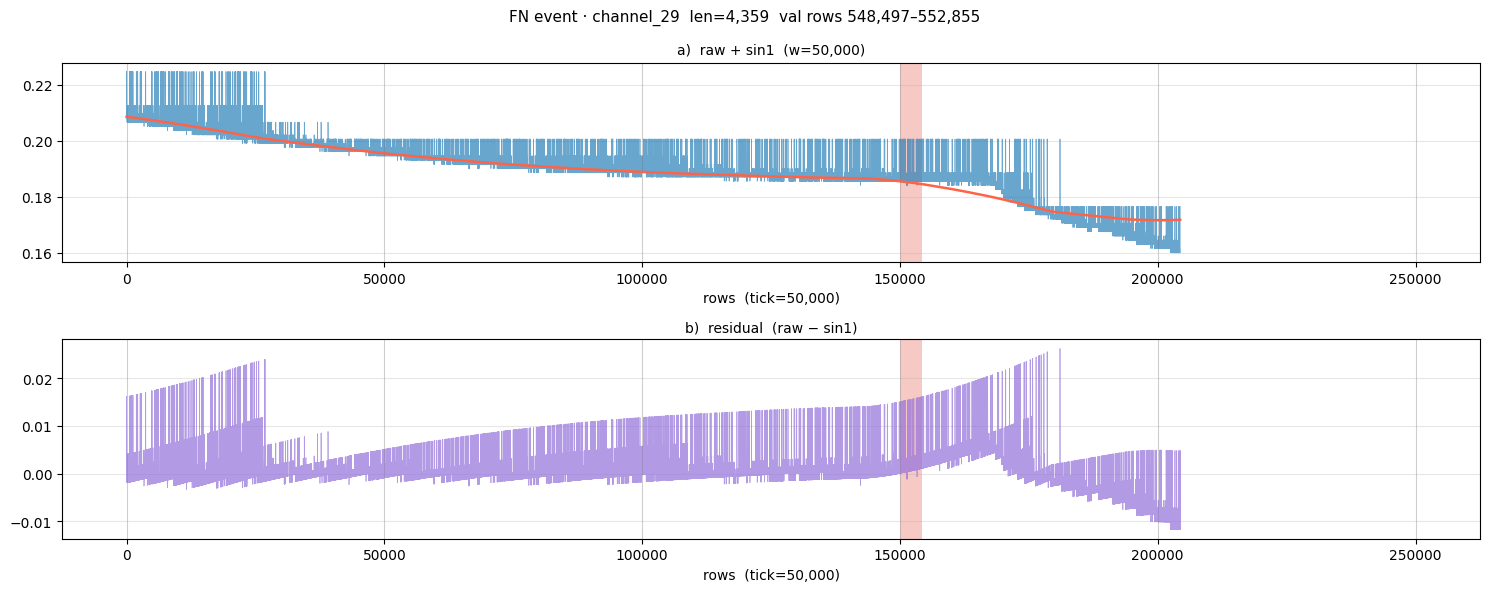

In [28]:
def _seg(ev, margin):
    """Return (start, end) clipped to z_val bounds with margin."""
    s = max(0, ev['start'] - margin)
    e = min(len(z_val) - 1, ev['end'] + margin)
    return s, e


def plot_fn_zscore_heatmap(ev, margin=MARGIN_EXPLORE):
    """Per-channel |z-score| heatmap + aggregated score vs threshold.

    Reading guide:
      - Row = channel, colour = |z| (white→yellow→red = 0→2→4+).
      - Blue dashed lines = FN event boundaries.
      - Dark rows inside lines → channel does not react → invisible to z-score.
      - Bright rows inside lines → channel reacts but aggregated score stays
        below threshold (check bottom panel: gap_to_thr from config cell).
    """
    s, e   = _seg(ev, margin)
    z_seg  = z_val.iloc[s : e + 1]
    xs     = np.arange(s, e + 1)
    an_s, an_e = ev['start'], ev['end']

    ch_list = list(z_val.columns)
    z_mat   = np.abs(z_seg[ch_list].values).T    # (n_ch, n_t)
    agg     = top_p_mean(z_seg[ch_list].values, p=best_p)

    fig, axes = plt.subplots(2, 1, figsize=(17, 5), sharex=True,
                             gridspec_kw={'height_ratios': [3, 1.5]})

    im = axes[0].imshow(
        z_mat, aspect='auto',
        extent=[xs[0], xs[-1], -0.5, len(ch_list) - 0.5],
        cmap='YlOrRd', vmin=0, vmax=4, origin='lower',
    )
    axes[0].set_yticks(range(len(ch_list)))
    axes[0].set_yticklabels(ch_list, fontsize=7)
    axes[0].axvline(an_s, color='steelblue', lw=1.5, ls='--', alpha=0.8)
    axes[0].axvline(an_e, color='steelblue', lw=1.5, ls='--', alpha=0.8)
    axes[0].set_title(
        f'|Z-score| per channel  |  FN  start={an_s:,}  end={an_e:,}  len={ev["length"]:,}',
        fontsize=9)
    plt.colorbar(im, ax=axes[0], label='|z|', shrink=0.8)

    axes[1].plot(xs, agg, lw=0.6, color=NOMINAL_COLOR)
    axes[1].axhline(best_thr, color='black', lw=1.2, ls='--',
                    label=f'threshold  {best_thr:.3g}')
    axes[1].fill_between(xs, 0, agg,
                         where=(xs >= an_s) & (xs <= an_e),
                         color=ANOMALY_COLOR, alpha=0.25, label='FN event')
    axes[1].set_ylabel('agg score')
    axes[1].legend(fontsize=8, loc='upper right')
    axes[1].set_xlabel('Val row index')
    plt.tight_layout()
    plt.show()


def plot_fn_other_channels(ev, channels=None, bw=_BIG_WIN):
    """Raw + sin1 (MA slow trend) + residual for VIZ_CHANNELS_OTHER."""
    if channels is None:
        channels = VIZ_CHANNELS_OTHER
    if not channels:
        print('VIZ_CHANNELS_OTHER is empty — add channel names to inspect.')
        return
    if _train_other.empty:
        print('_train_other not loaded — re-run config cell with VIZ_CHANNELS_OTHER set.')
        return

    an_s_tr = tr_end + ev['start']
    an_e_tr = tr_end + ev['end']
    win_s   = max(0, an_s_tr - 3 * bw)
    win_e   = min(len(_train_other), an_e_tr + 1 + bw)

    for ch in channels:
        raw  = _train_other[ch].values[win_s:win_e].astype(np.float64)
        sin1 = _uf1d(raw, size=bw, mode='nearest')
        res  = raw - sin1

        n   = len(raw)
        a0  = an_s_tr - win_s
        a1  = an_e_tr - win_s + 1

        specs = [
            (raw, sin1, NOMINAL_COLOR, 'tomato',   f'a)  raw + sin1  (w={bw:,})'),
            (res, None, 'mediumpurple', None,       f'b)  residual  (raw − sin1)'),
        ]

        fig, axes = plt.subplots(2, 1, figsize=(15, 6), sharex=False)
        for ax, (base, comp, c_base, c_comp, title) in zip(axes, specs):
            ax.plot(np.arange(n), base, lw=0.5, alpha=0.7, color=c_base)
            if comp is not None:
                ax.plot(np.arange(n), comp, lw=1.8, color=c_comp)
            ax.axvspan(max(0, a0), min(a1, n), color=ANOMALY_COLOR, alpha=0.3, linewidth=0)
            for k in range(n // bw + 2):
                ax.axvline(k * bw, color='gray', lw=0.5, alpha=0.35)
            ax.set_title(title, fontsize=10)
            ax.set_xlabel(f'rows  (tick={bw:,})')
            ax.grid(True, alpha=0.3)

        fig.suptitle(
            f'FN event · {ch}  len={ev["length"]:,}  val rows {ev["start"]:,}–{ev["end"]:,}',
            fontsize=11,
        )
        plt.tight_layout()
        plt.show()


for ev in fn_target:
    print(f'\n{"─" * 60}')
    print(f'FN  start={ev["start"]:,}  end={ev["end"]:,}  len={ev["length"]:,}')
    plot_fn_zscore_heatmap(ev)
    plot_fn_other_channels(ev)

## Test inference & submission

In [29]:
freq_cols = [c for c in CHANNELS if not c.endswith('_envr')]
env_cols  = [c for c in CHANNELS if c.endswith('_envr')]

parts_test = []
if freq_cols:
    parts_test.append(rolling_zscore_df(test[freq_cols], ROLLING_WINDOW))
if env_cols:
    parts_test.append(test[env_cols] / std_tr_env)  # std_tr_env fitted on train in z_full cell

z_test      = pd.concat(parts_test, axis=1)[CHANNELS]
scores_test = top_p_mean(z_test.values, p=best_p)
y_pred_test = (scores_test > best_thr).astype(int)

sub      = pd.DataFrame({'id': test.index, 'is_anomaly': y_pred_test})
out_path = SUB_DIR / 'ek_indi_zscore_41_46_14_21_29.csv'
sub.to_csv(out_path, index=False)
print(f'Saved  {out_path}')
print(f'Predicted anomaly rate: {y_pred_test.mean():.4%}')